# PROPEL Preprocessing 
PREDICTIVE ANALYTICS FOR MENTAL HEALTH: IDENTIFYING FACTORS INFLUENCING SUCCESSFUL TALK THERAPY OUTCOMES

In [219]:
## Load necessary packages
import pandas as pd 
import os
import numpy as np 
import seaborn as sns 
import platform
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import zscore, ttest_rel, f_oneway, chi2_contingency
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf

## Ensure all figures are in TNR 
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams.update({"font.size": 16})
randomstate = 42

In [220]:
df = pd.read_csv("propel_consent.csv")

# Data Preprocessing 

In [221]:
df.head()

,ID,site_ID,ethnicity,age,employment_status,retirement_duration,benefits,education_level,education_total,current_mh_duration,...,WSAS_diff_std,rel_improv_2,rel_recovery,rel_deterioration_2,rel_change_2,treatment_a_2,treatment_b_2,mh_doi,mh_onset_cat,education_level_2
0,11326,27,"Welsh, English, Scottish, Northern Irish or Br...",49,Self-employed,NaN,No,"Professional qualifications, e.g. teaching, nu...",8,More than 12 months,...,-0.039109,Y,1.0,N,Y,CFD,NaN,18.0,adulthood,"Professional qualifications, e.g. teaching, nu..."
1,11355,23,"Welsh, English, Scottish, Northern Irish or Br...",33,Self-employed,NaN,No,NVQ or BTEC,18,More than 12 months,...,-0.872396,Y,1.0,N,Y,IPT,NaN,10.0,adulthood,Further education
2,11375,21,"Welsh, English, Scottish, Northern Irish or Br...",70,Retired,13,No,No formal qualifications,10,More than 12 months,...,1.314983,Y,1.0,N,Y,CBT,NaN,3.0,adulthood,No formal qualifications
3,11426,17,"Welsh, English, Scottish, Northern Irish or Br...",29,Employed (full-time),NaN,No,Bachelor's degree,18,More than 12 months,...,-1.601522,Y,1.0,N,Y,CFD,NaN,4.0,adulthood,Higher education
4,11510,12,"Welsh, English, Scottish, Northern Irish or Br...",58,Employed (full-time),NaN,No,Bachelor's degree,16,6 - 12 months,...,-0.664074,Y,1.0,N,Y,CFD,NaN,30.0,adulthood,Higher education


In [186]:
df.describe()

,ID,site_ID,age,mh_onset,perc_health_1,perc_health_2,perc_health_3,perc_health_4,lonely_1,lonely_2,...,PDSS_diff,PDSS_diff_std,MI_diff,MI_diff_std,HAI_diff,HAI_diff_std,WSAS_diff,WSAS_diff_std,rel_recovery,mh_doi
count,926.000000,926.000000,926.000000,880.000000,909.000000,909.00000,898.000000,907.000000,908.000000,909.000000,...,6.000000,6.000000,2.000000,2.000000,3.000000,3.000000,760.000000,760.000000,893.000000,880.000000
mean,54730.965443,18.005400,43.795896,26.577273,2.240924,0.89989,3.446548,2.084895,2.094714,2.148515,...,-12.000000,0.000000,-5.750000,0.000000,-11.333333,0.000000,-6.577632,0.004886,0.516237,17.068182
std,25653.945649,8.721702,16.908735,16.660730,1.033704,1.14186,2.901185,0.979065,0.743850,0.745730,...,5.865151,1.000000,6.010408,1.000000,6.806859,1.000000,9.499284,0.989454,0.500016,15.544275
min,11326.000000,1.000000,18.000000,3.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,...,-18.000000,-1.022992,-10.000000,-0.707107,-19.000000,-1.126315,-40.000000,-3.476417,0.000000,0.000000
25%,32904.500000,11.000000,30.000000,14.000000,2.000000,0.00000,1.000000,1.000000,2.000000,2.000000,...,-16.250000,-0.724619,-7.875000,-0.353553,-14.000000,-0.391762,-13.000000,-0.664074,0.000000,5.000000
50%,55143.000000,20.000000,42.000000,20.000000,2.000000,0.00000,3.000000,2.000000,2.000000,2.000000,...,-13.500000,-0.255748,-5.750000,0.000000,-9.000000,0.342791,-6.000000,0.065052,1.000000,12.000000
75%,76160.250000,27.000000,57.000000,35.000000,3.000000,2.00000,6.000000,3.000000,3.000000,3.000000,...,-8.500000,0.596745,-3.625000,0.353553,-7.500000,0.563157,0.000000,0.690017,1.000000,26.000000
max,99950.000000,30.000000,98.000000,90.000000,4.000000,4.00000,10.000000,4.000000,3.000000,3.000000,...,-3.000000,1.534487,-1.500000,0.707107,-6.000000,0.783523,30.000000,3.814843,1.000000,82.000000


In [187]:
## Check for duplicates
duplicates = df.duplicated().any()

if duplicates == False:
    print ("There are no duplicates.")
else:
    print ("There are duplicates.")

There are no duplicates.


### Remove participants who do not meet caseness
Participants qualify for reliable recovery only if they meet "caseness" prior to treatment.

In [188]:
df.caseness.value_counts(dropna=False)

caseness
Y    893
N     33
Name: count, dtype: int64

In [189]:
df_rr = df[df["caseness"] != "N"]

df_rr.caseness.value_counts(dropna=False)

caseness
Y    893
Name: count, dtype: int64

In [190]:
df_rr.gender.value_counts(dropna=False)

gender
female        641
male          240
non-binary      8
NaN             4
Name: count, dtype: int64

## Pick which columns to keep 
The NHS TT data has columns that have been previously transformed or do not relate to our analyses.

In [191]:
for col in df_rr.columns:
    print(col)

ID
site_ID
ethnicity
age
employment_status
retirement_duration
benefits
education_level
education_total
current_mh_duration
previous_mh
mh_onset
mh_other
mh_other_2
mh_meds
physical_problems
physical_problems_2
perc_health_1
perc_health_2
perc_health_3
perc_health_4
lonely_1
lonely_2
lonely_3
lonely_4
loc_1
loc_2
loc_3
loc_4
loc_5
loc_6
loc_7
loc_8
loc_9
loc_10
loc_11
loc_12
pers_1
pers_2
pers_3
pers_4
pers_5
pers_6
pers_7
pers_8
pers_9
pers_10
sensitive_questions
selfcomp_1
selfcomp_2
selfcomp_3
selfcomp_4
selfcomp_5
selfcomp_6
selfcomp_7
selfcomp_8
selfcomp_9
selfcomp_10
selfcomp_11
selfcomp_12
selfcomp_13
selfcomp_14
selfcomp_15
selfcomp_16
selfcomp_17
selfcomp_18
selfcomp_19
selfcomp_20
resilience_1
resilience_2
resilience_3
resilience_4
resilience_5
resilience_6
resilience_7
resilience_8
resilience_9
resilience_10
stresslife_1
stresslife_2
stresslife_3
stresslife_4
stresslife_5
stresslife_6
stresslife_7
stresslife_8
stresslife_9
stresslife_10
stresslife_11
stresslife_12
stresslife

In [192]:
columns_remove = ["retirement_duration", "sensitive_questions", "perc_health_1", "perc_health_2", "perc_health_3", "perc_health_4", "lonely_1",
                  "lonely_2", "lonely_3", "lonely_4", "loc_1", "loc_2", "loc_3", "loc_4", "loc_5", "loc_6", "loc_7", "loc_8", "loc_9", "loc_10",
                  "loc_11", "loc_12", "pers_1", "pers_2", "pers_3", "pers_4", "pers_5", "pers_6", "pers_7", "pers_8", "pers_9", "pers_10", "education_total", 
                  "education_level", "mh_other_2", "OCI_pre", "SPIN_pre", "selfcomp_1", "selfcomp_2", "selfcomp_3", "selfcomp_4", "selfcomp_5", "selfcomp_6", 
                  "selfcomp_7", "selfcomp_8", "selfcomp_9", "selfcomp_10", "selfcomp_11", "selfcomp_12", "selfcomp_13", "selfcomp_14", "selfcomp_15", "selfcomp_16",
                  "selfcomp_17", "selfcomp_18", "selfcomp_19", "selfcomp_20", "resilience_1", "resilience_2", "resilience_3", "resilience_4", "resilience_5", 
                  "resilience_6", "resilience_7", "resilience_8", "resilience_9", "resilience_10", "stresslife_1", "stresslife_2", "stresslife_3", "stresslife_4",
                  "stresslife_5", "stresslife_6", "stresslife_7", "stresslife_8", "stresslife_9", "stresslife_10", "stresslife_11", "stresslife_12", "stresslife_13",
                  "stresslife_14", "stresslife_15", "stresslife_16", "stresslife_17", "stresslife_18", "stresslife_19", "stresslife_20", "stresslife_21",
                  "stresslife_22", "stresslife_23", "stresslife_24", "stresslife_25", "stresslife_26", "stresslife_27", "stresslife_28", "stresslife_29",
                  "stresslife_30", "stresslife_31", "stresslife_32", "impact_1", "impact_2", "impact_3", "impact_4", "impact_5", "impact_6", "cope_1", 
                  "cope_2", "cope_3", "cope_4", "cope_5", "cope_6", "cope_7", "cope_8", "cope_9", "cope_10", "cope_11", "cope_12", "cope_13", "cope_14", 
                  "cope_15", "cope_16", "cope_17", "cope_18", "cope_19", "cope_20", "cope_21", "cope_22", "cope_23", "cope_24", "cope_25", "cope_26",
                  "cope_27", "cope_28", "MI_pre", "PCL5_pre", "PDSS_pre", "HAI_pre", "sessions_off_a", "sessions_att_a", "condition", "GAD7_diff_std",
                 "step_b", "treatment_b", "sessions_off_b", "sessions_att_b", "OCI_post", "SPIN_post", "MI_post", "WSAS_diff_std", "PHQ9_diff_std",
                  "PCL5_post", "PDSS_post", "HAI_post", "treatment_end", "sessions_total", "treat_active", "ethnicity", "rel_change_2",
                 "employment_status", "lonely_total", "age_group_2", "stresslife_total_new", "treatment_a", "rel_deterioration_2",
                 "treatment_b_2", "SPIN_diff", "SPIN_diff_std", "OCI_diff", "OCI_diff_std", "PCL5_diff", "PCL5_diff_std", 
                  "PDSS_diff", "PDSS_diff_std", "MI_diff", "MI_diff_std", "HAI_diff", "HAI_diff_std", "physical_problems_2", "rel_improv_2"]

df_rr_clean = df_rr.drop(columns=columns_remove)


## Outliers 
Check for any outliers and distribution of continuous variables using Z-score method.

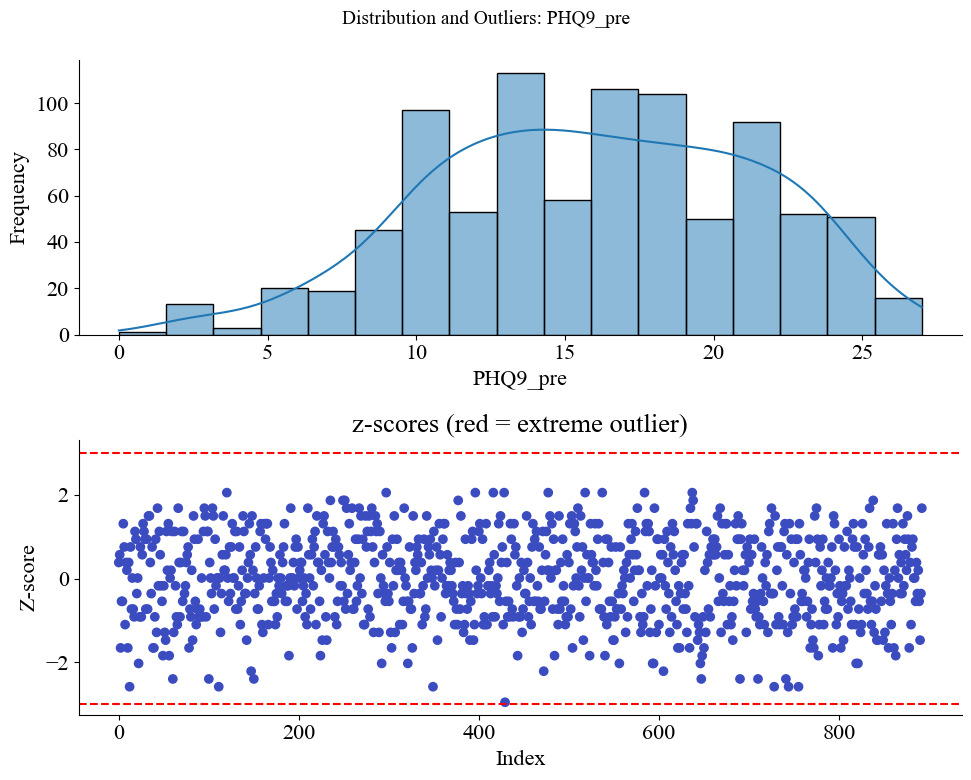

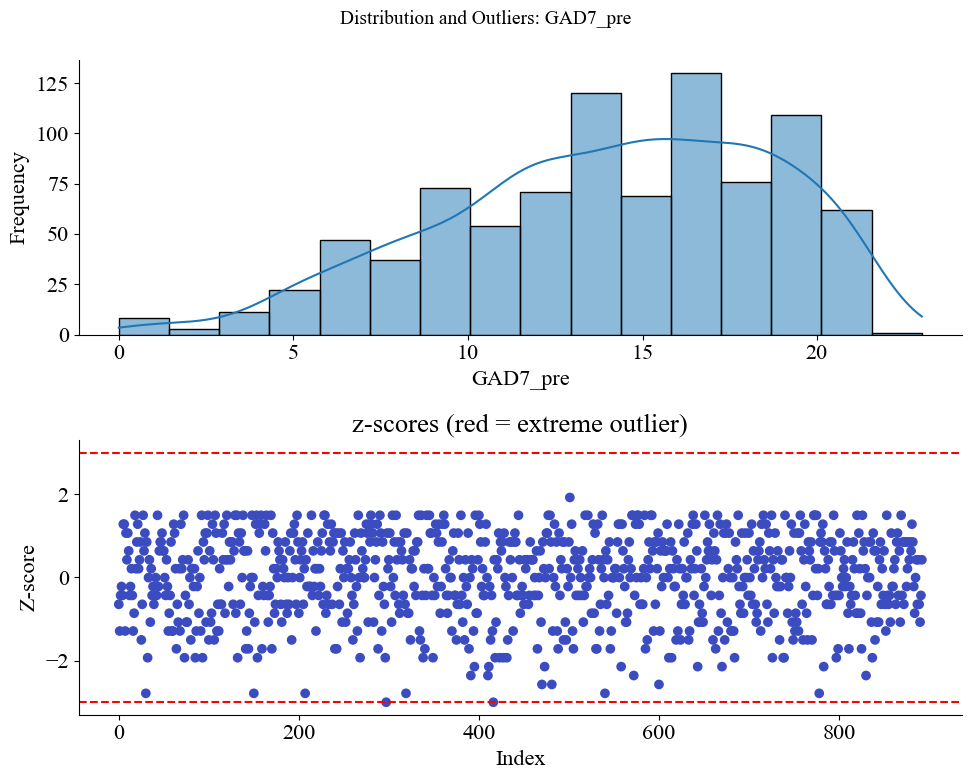

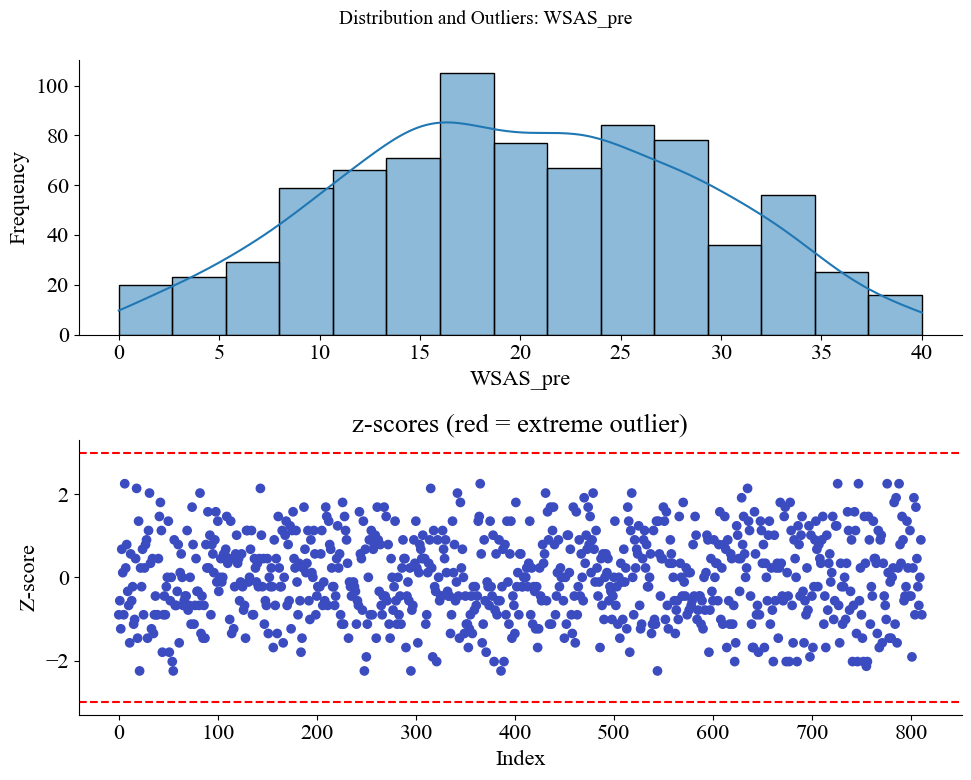

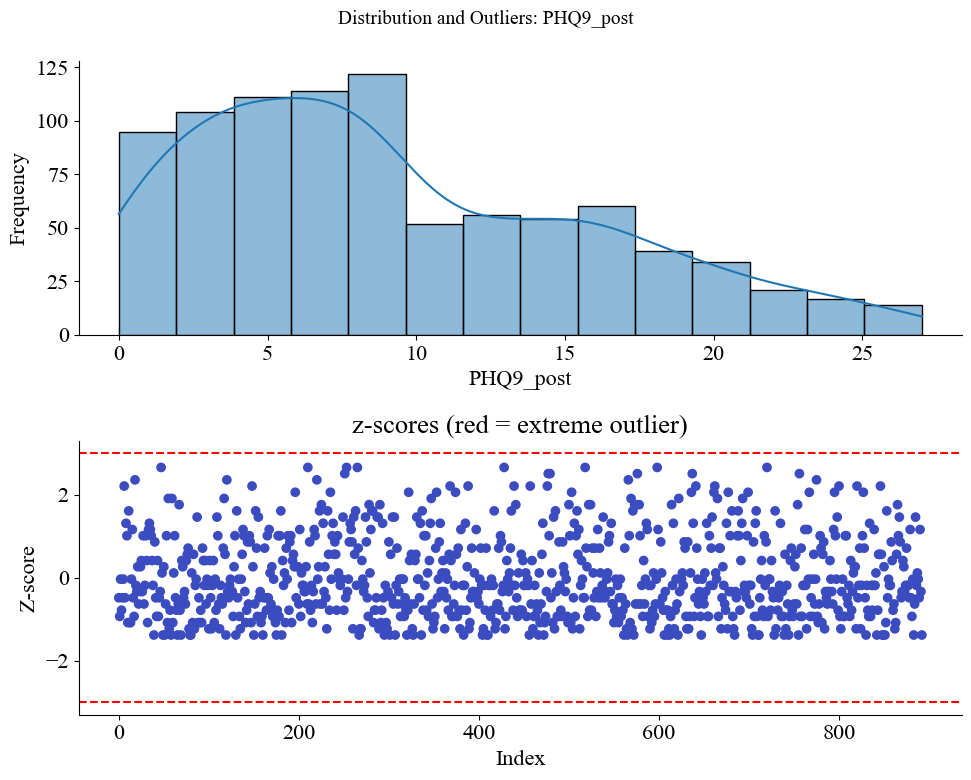

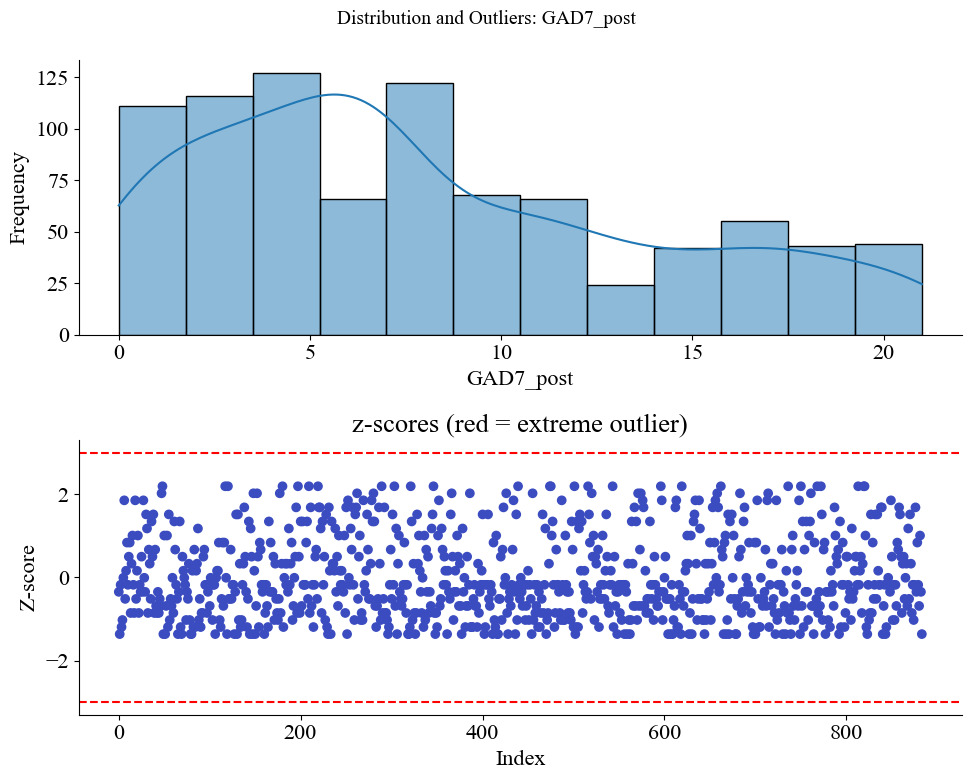

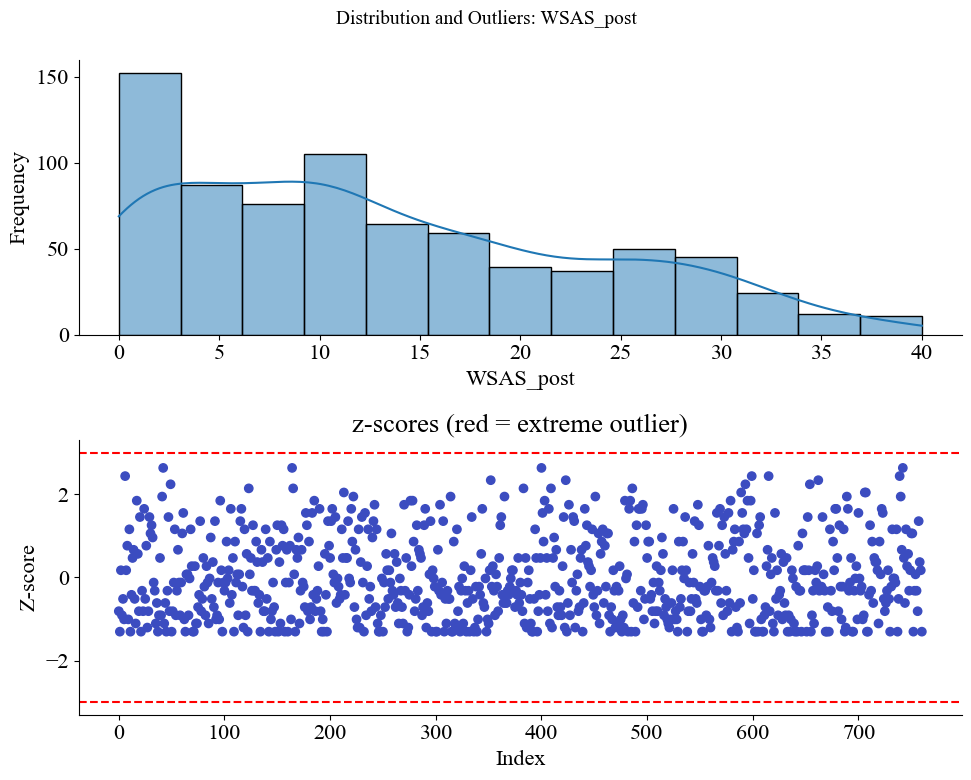

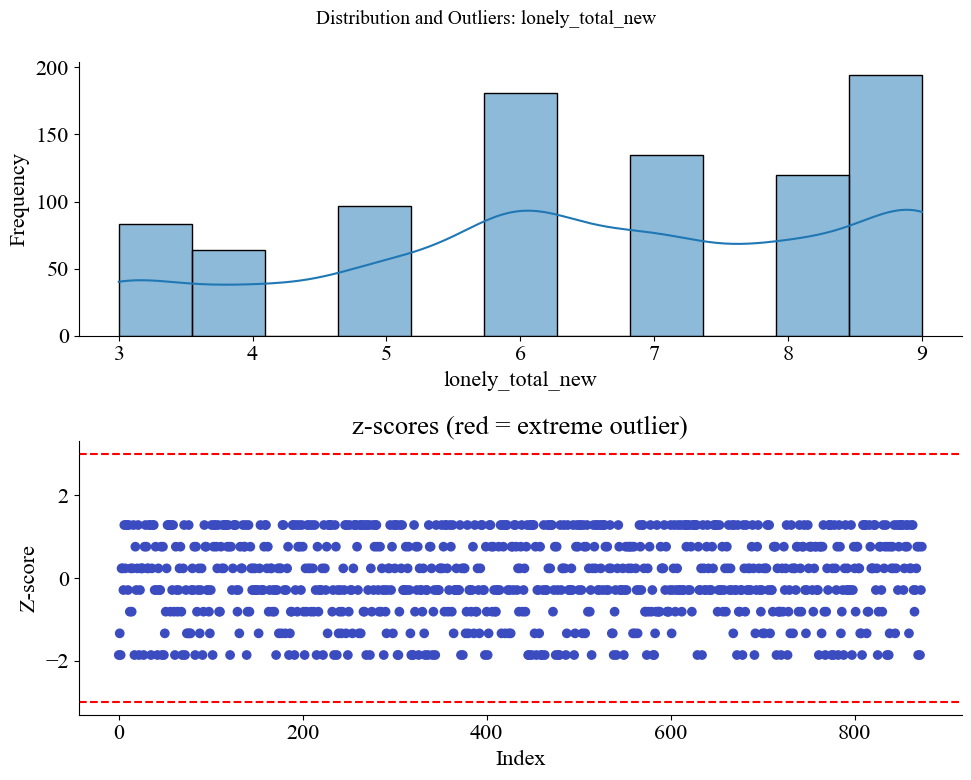

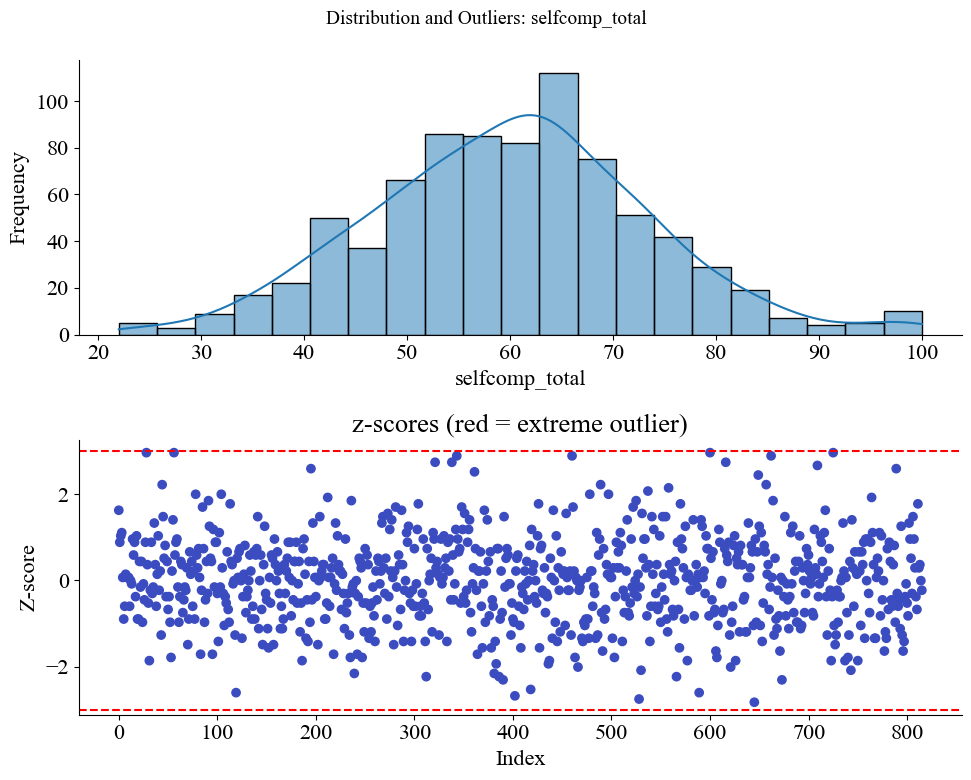

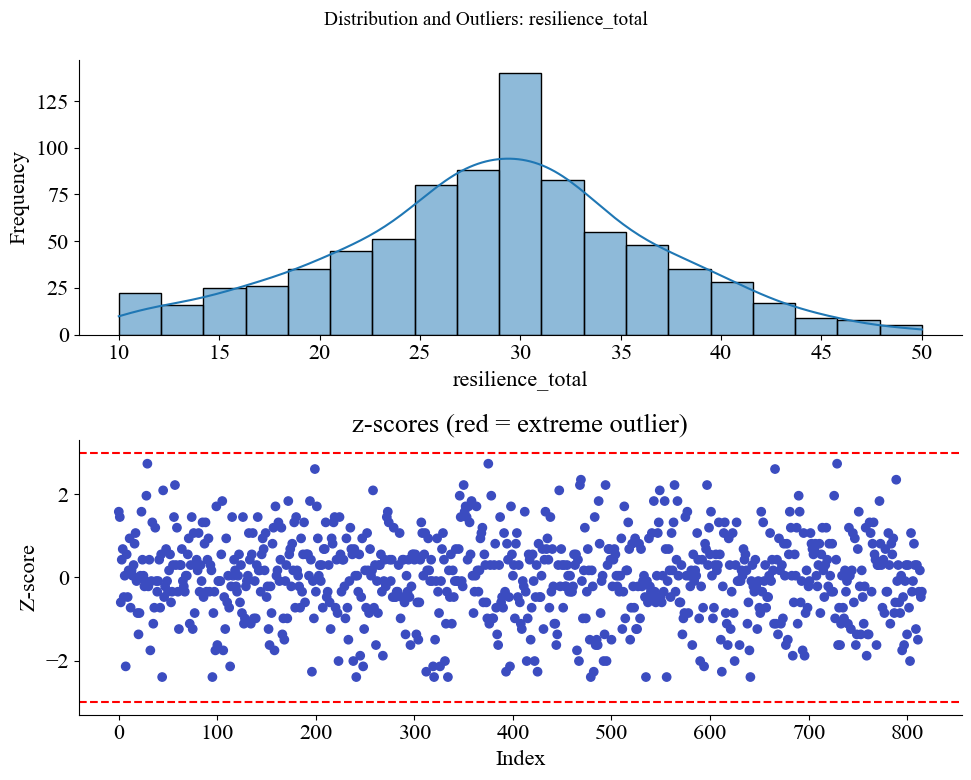

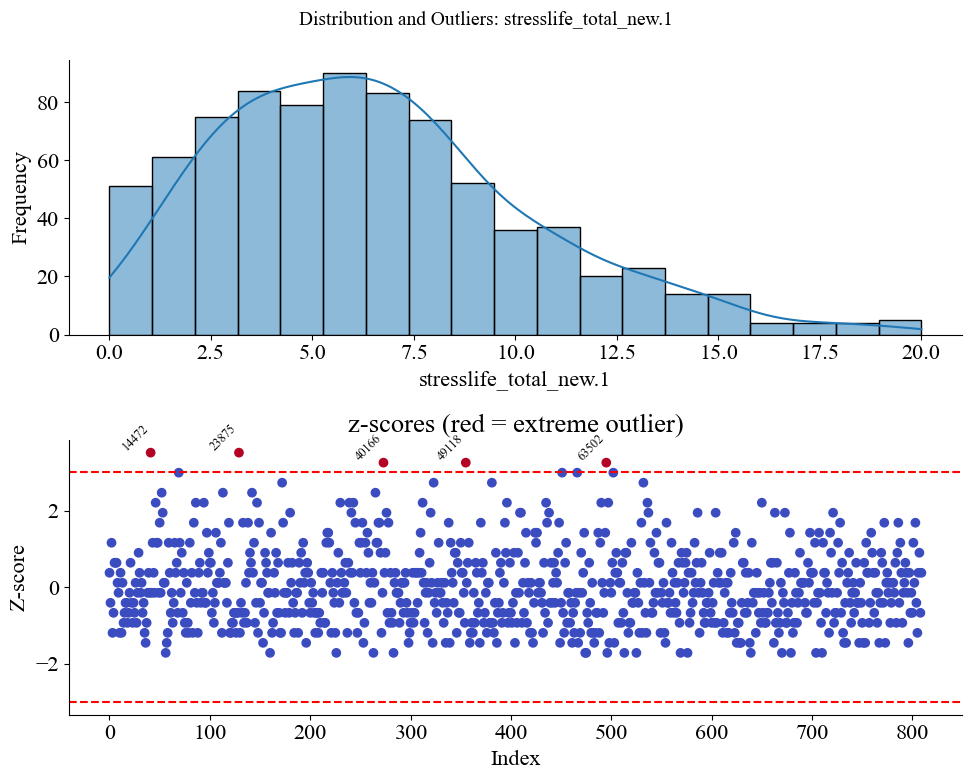

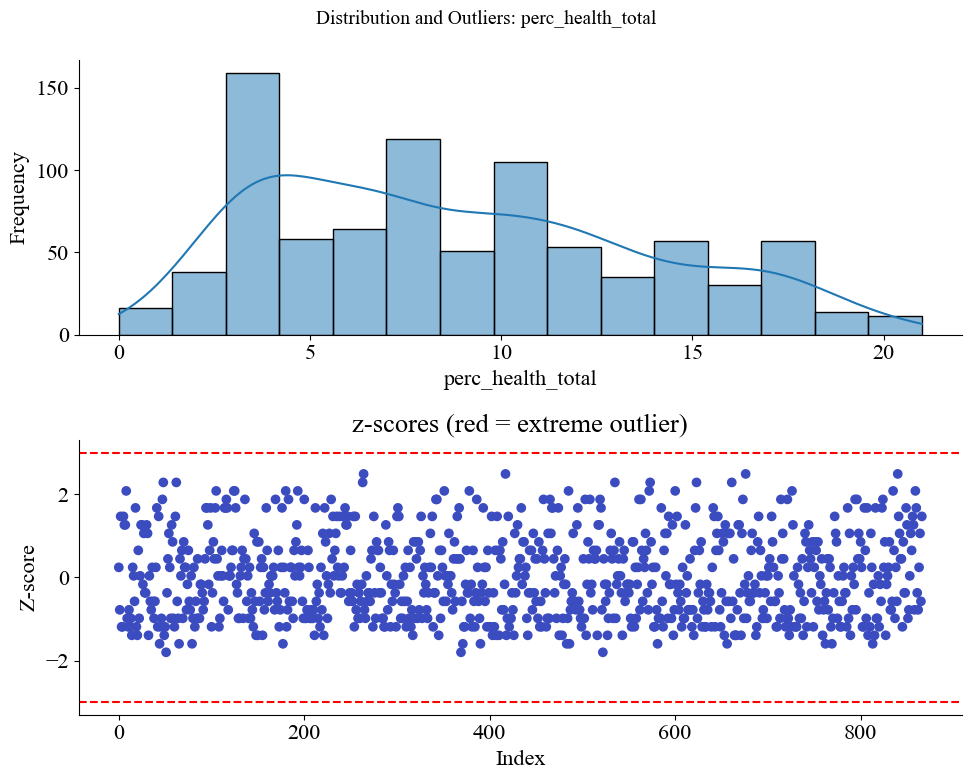

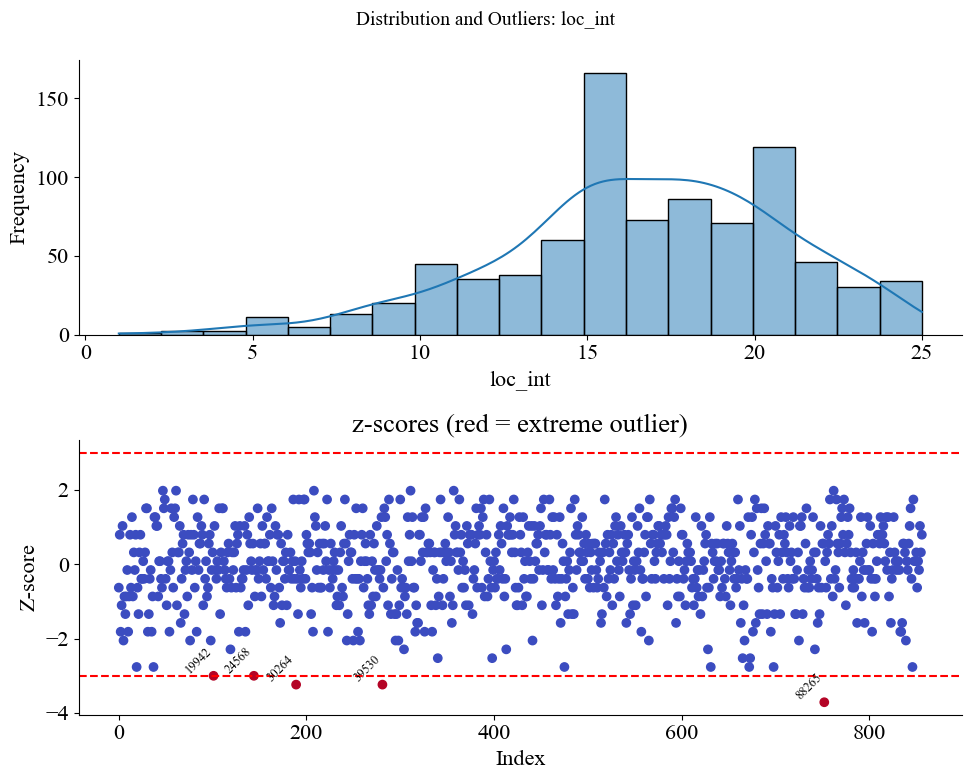

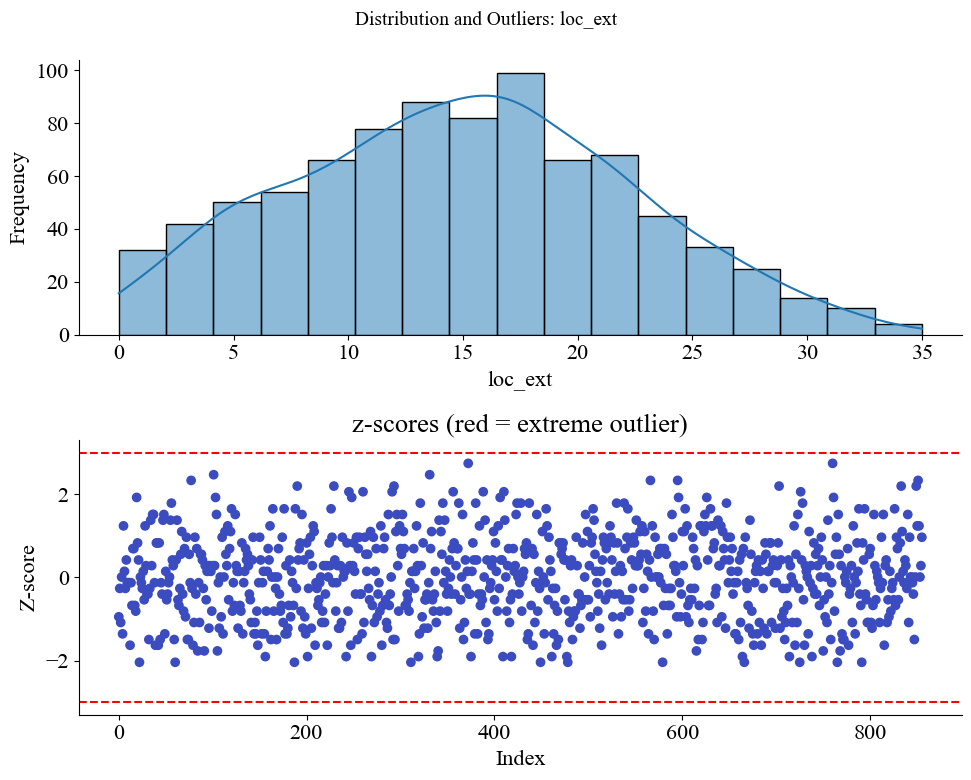

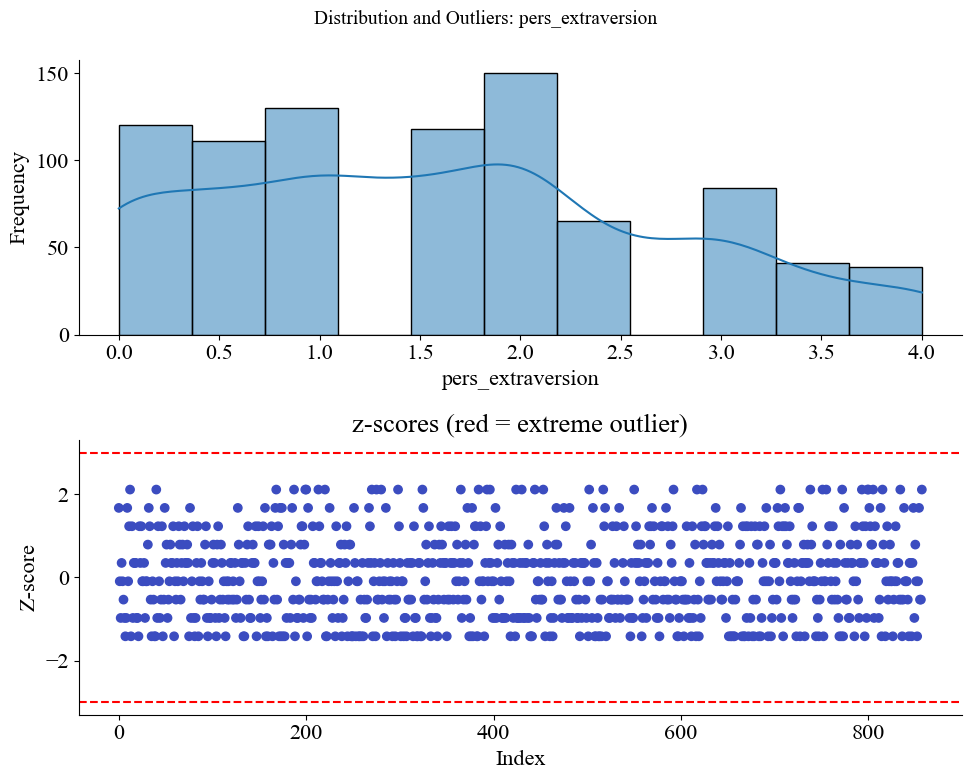

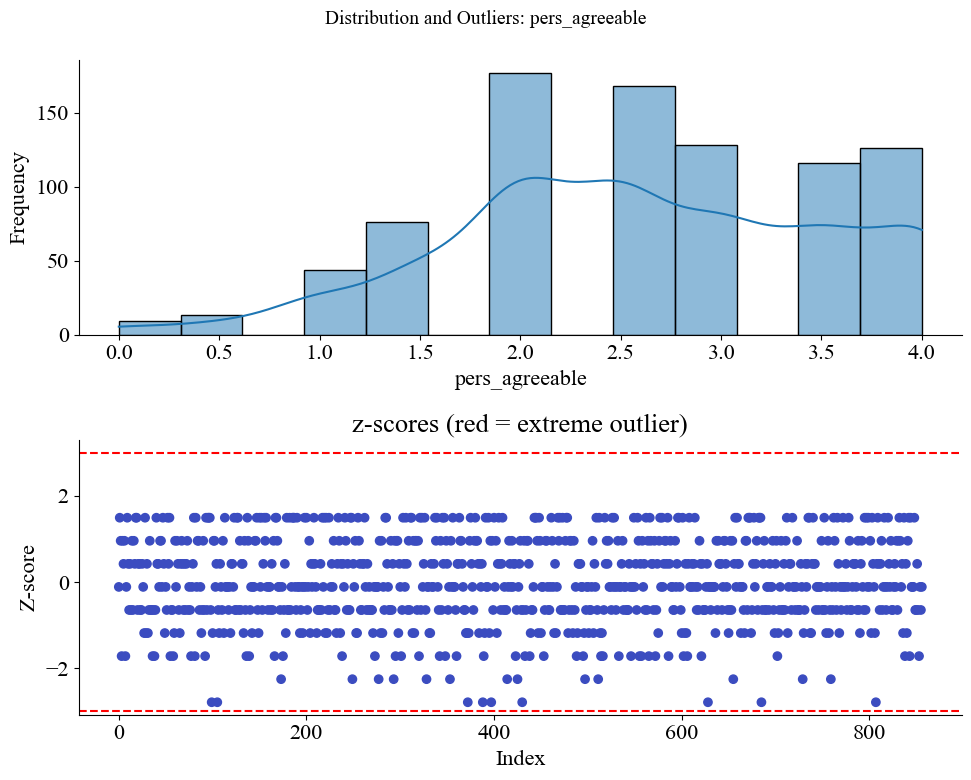

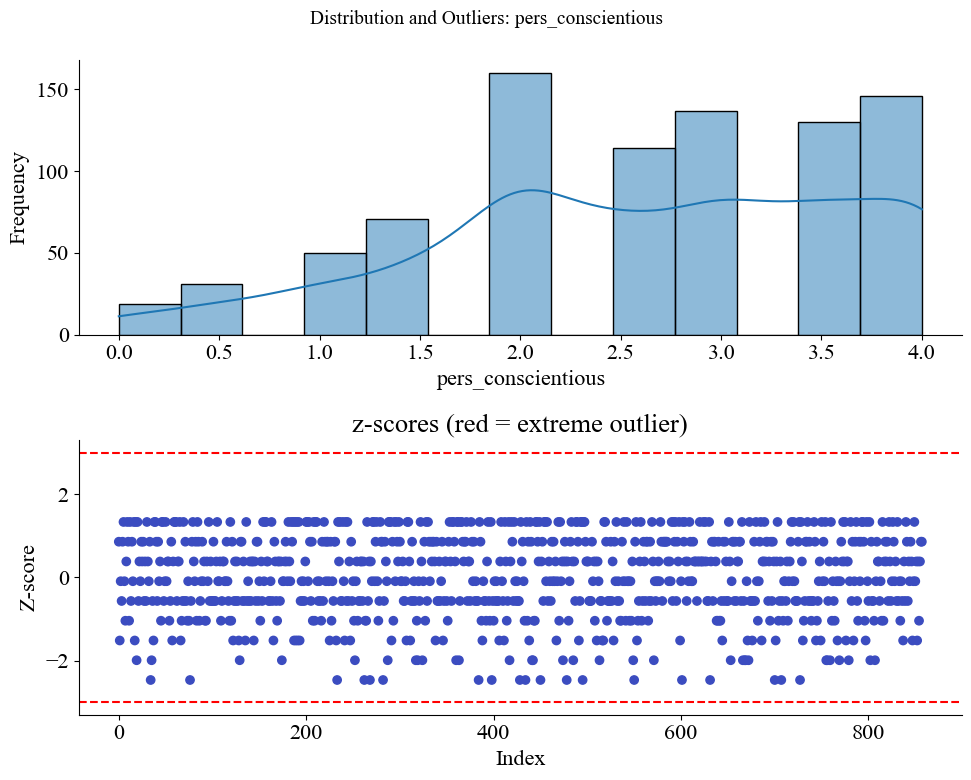

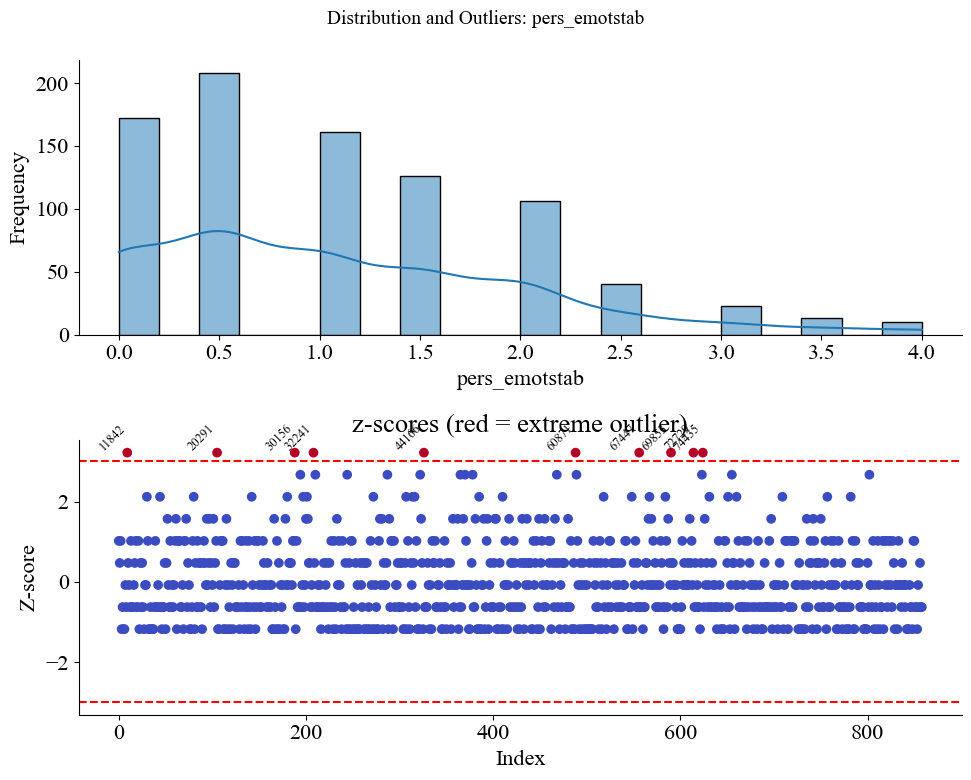

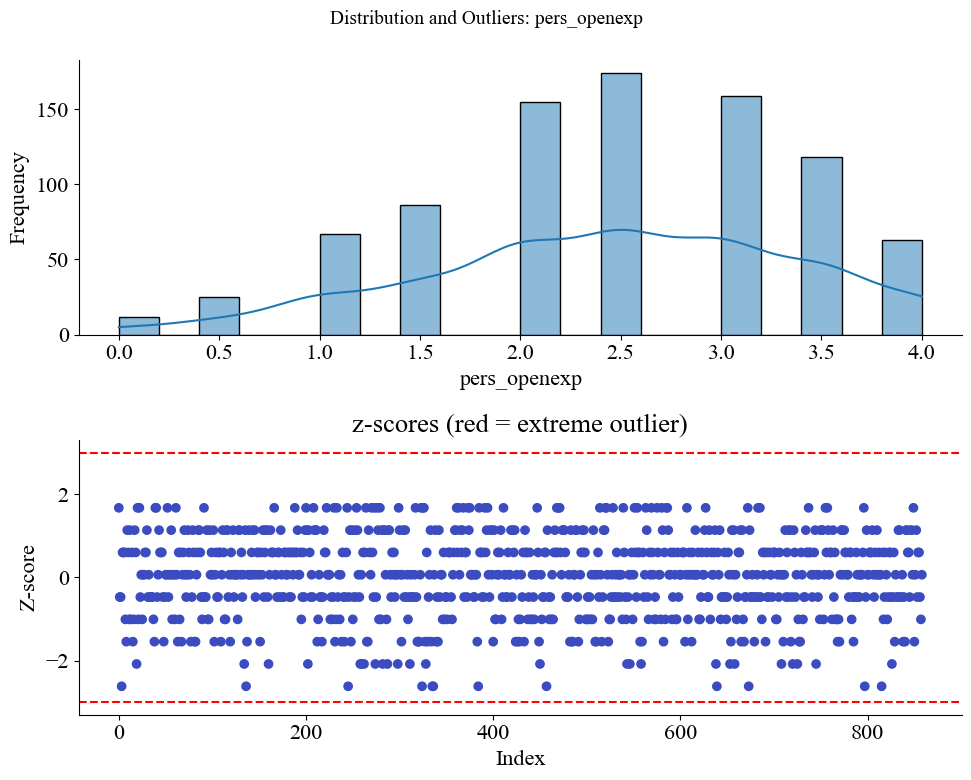

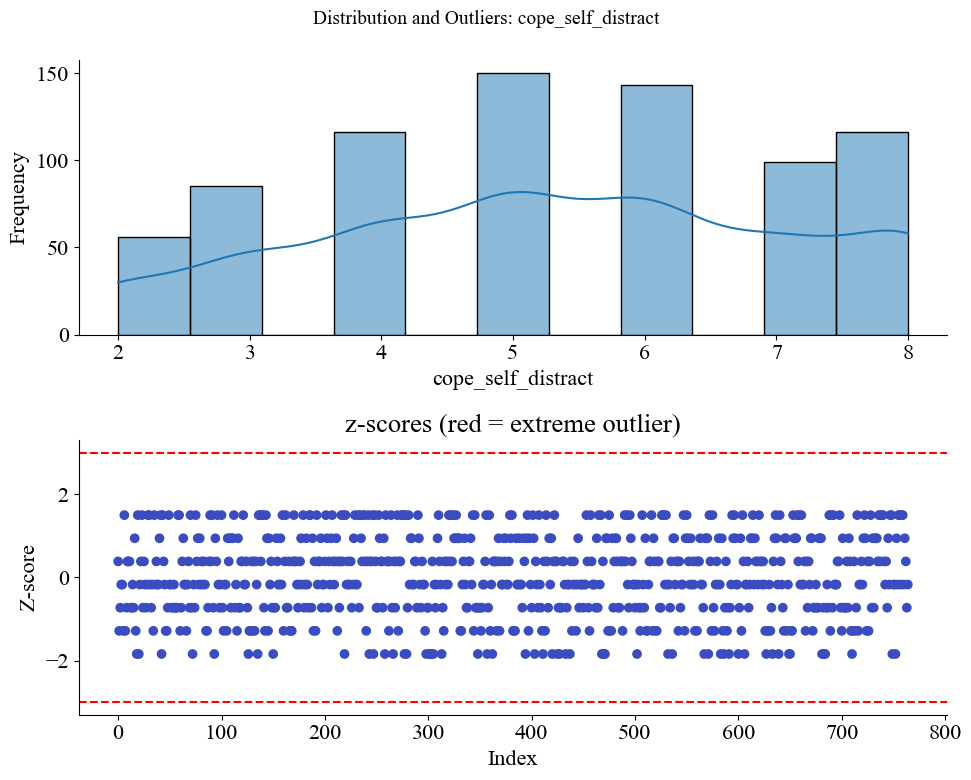

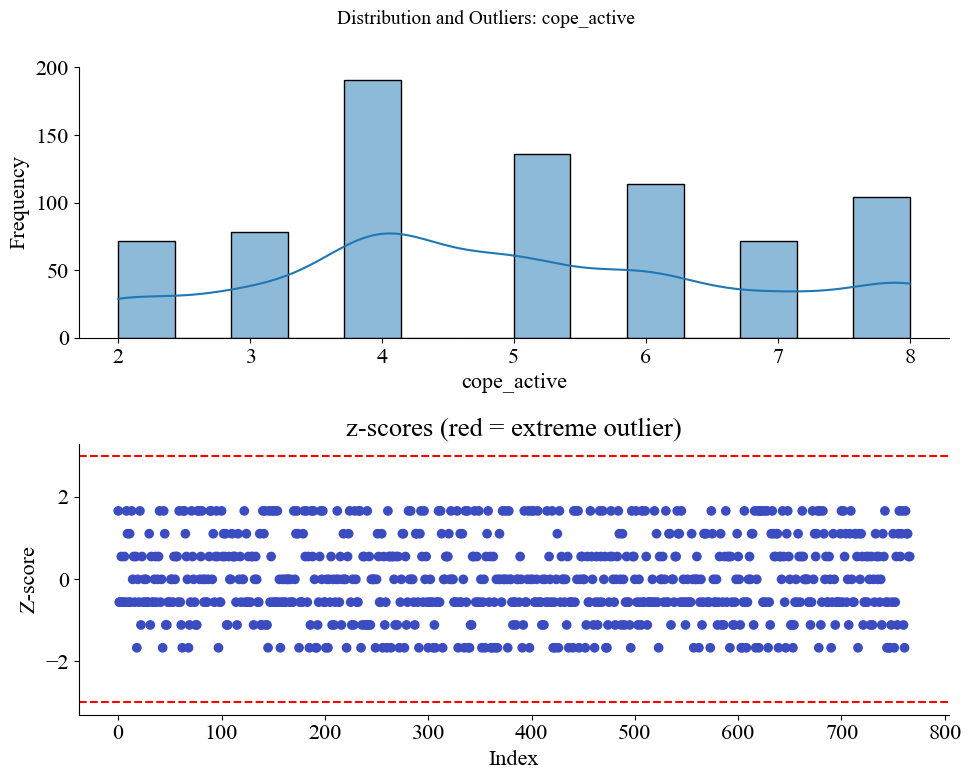

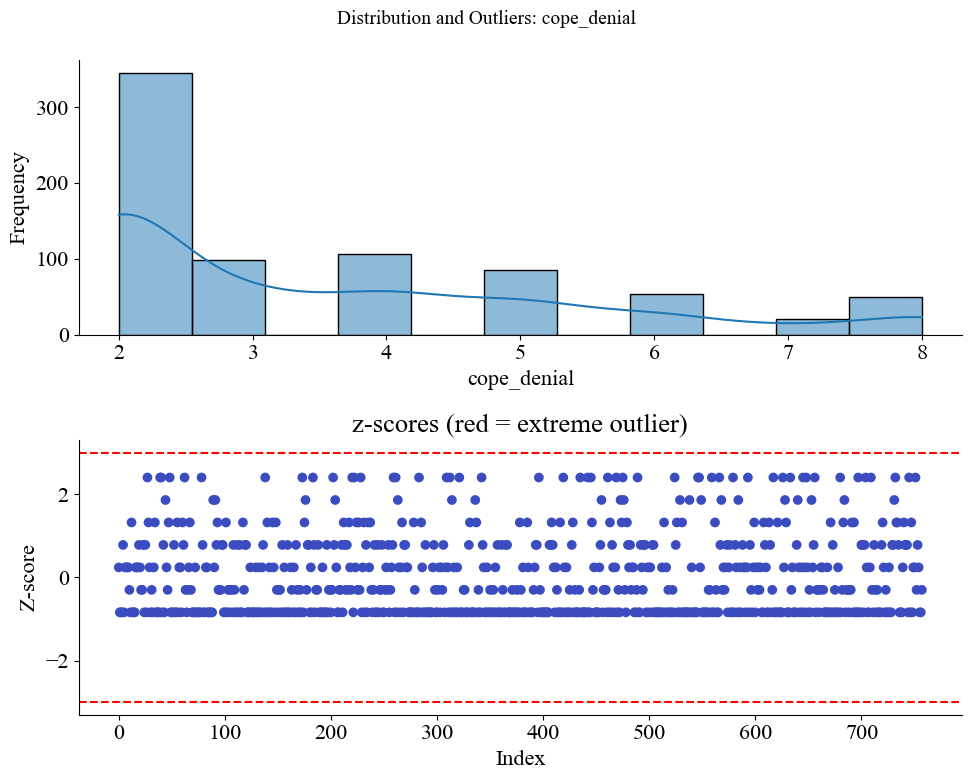

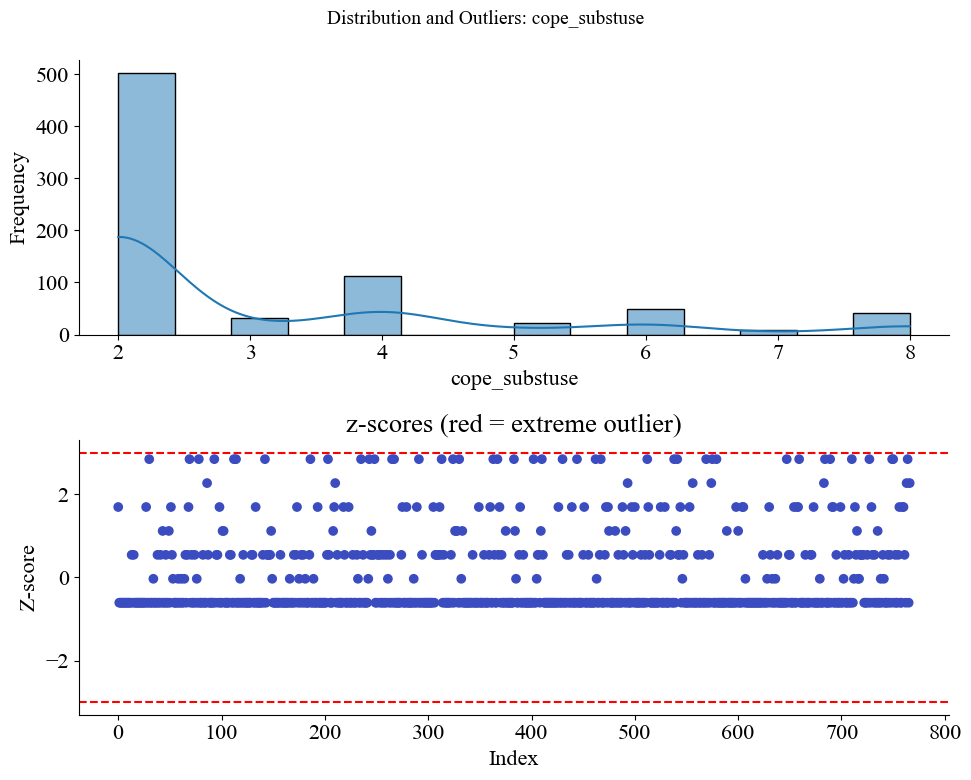

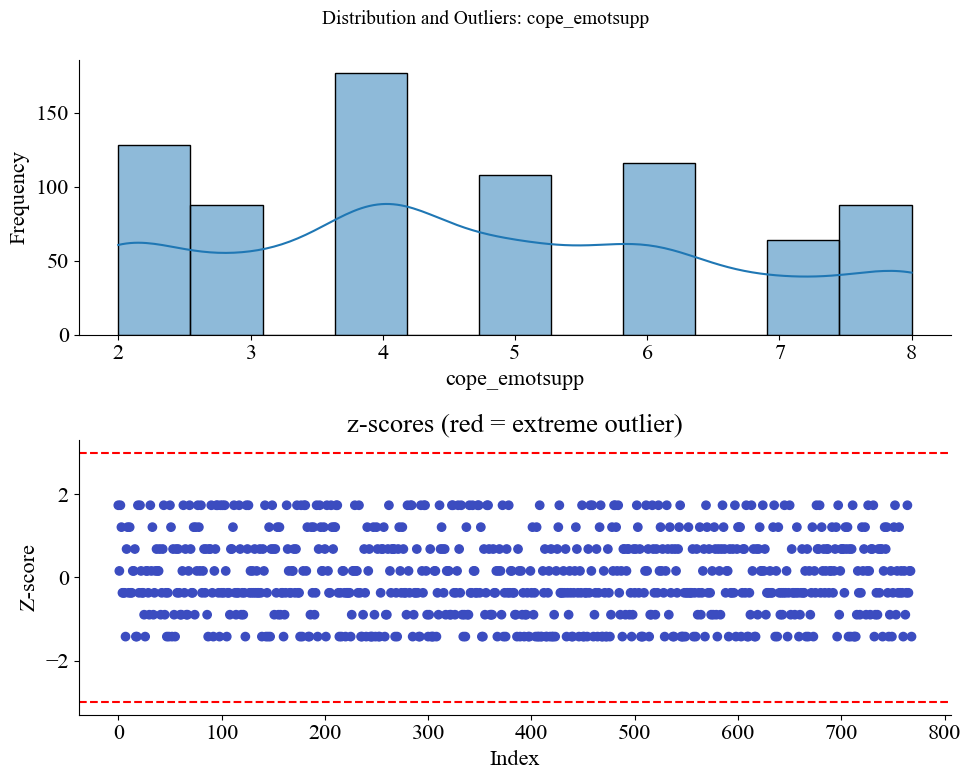

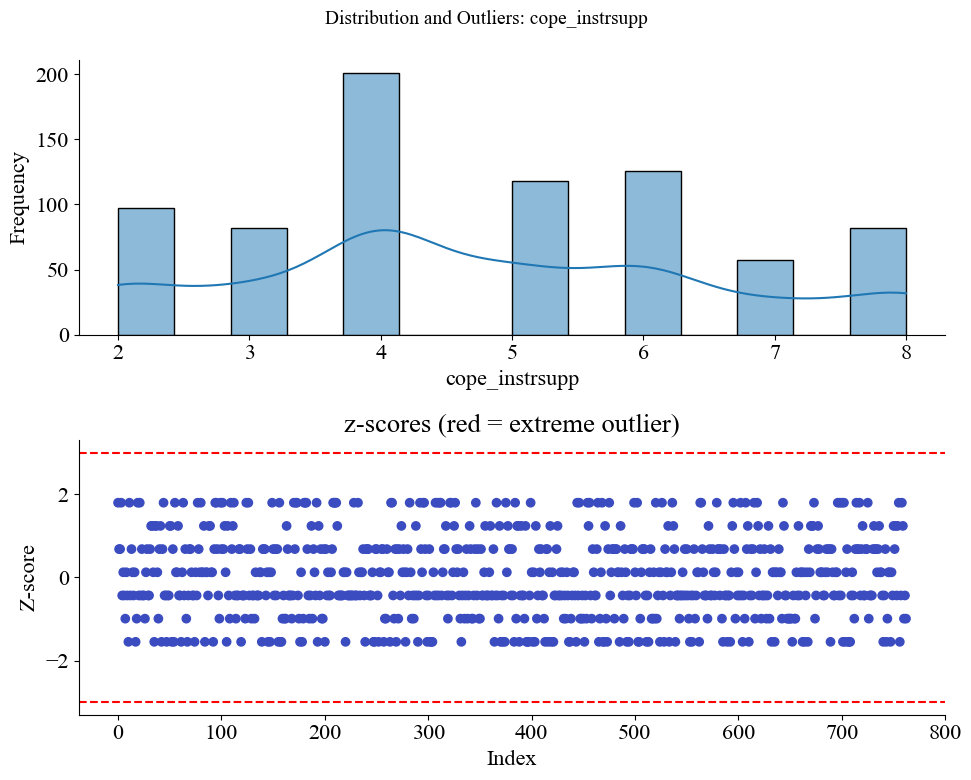

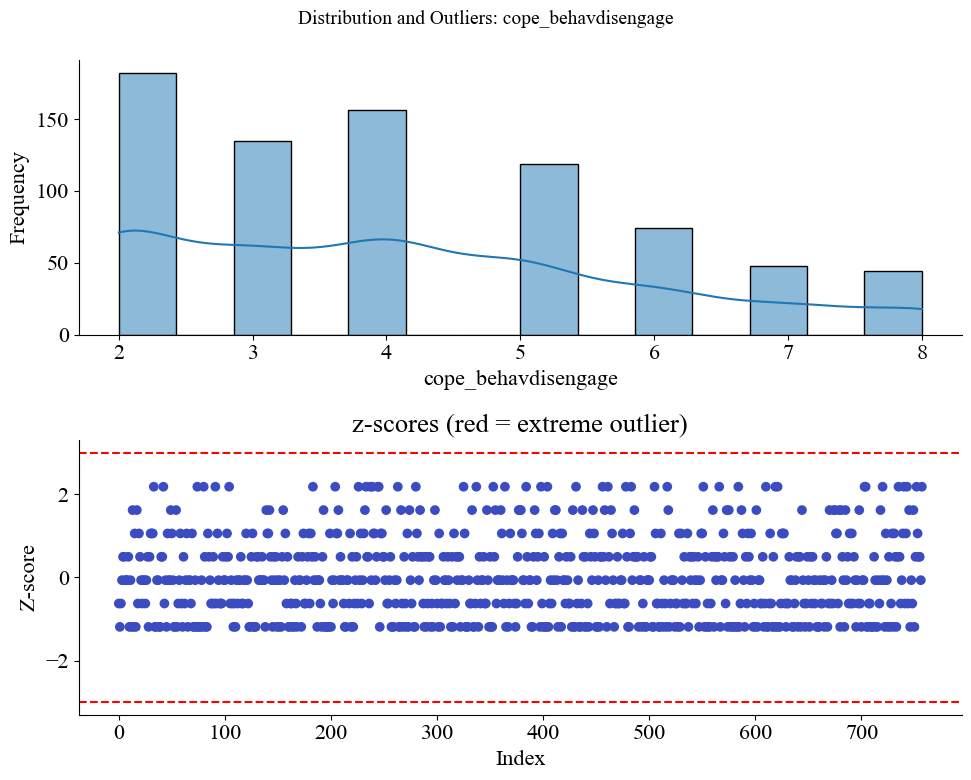

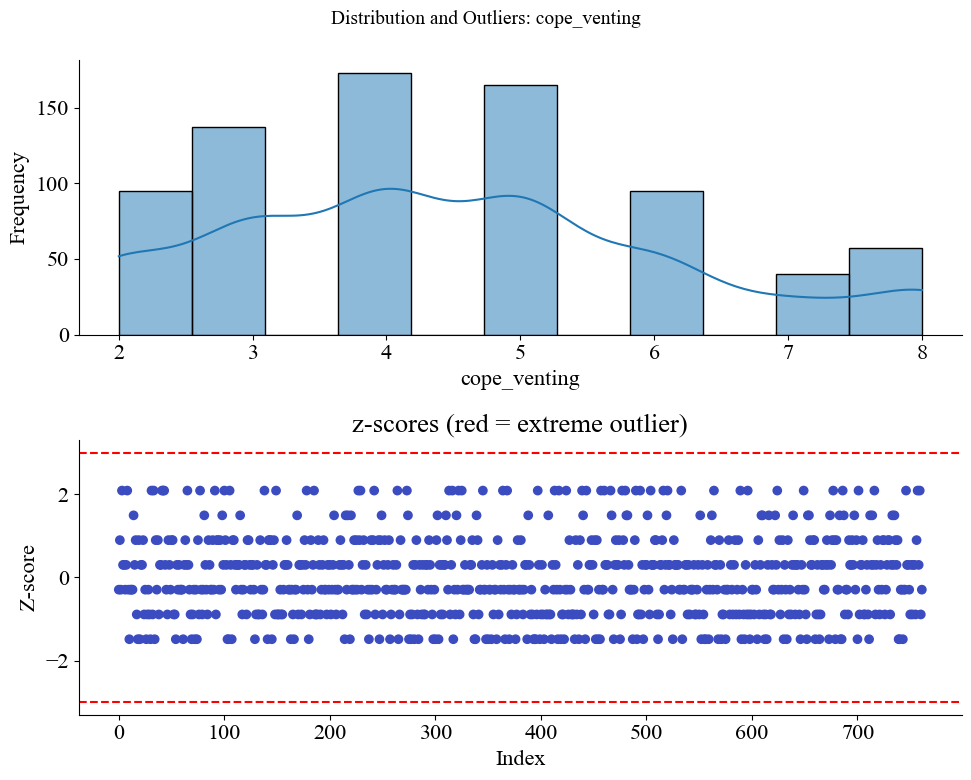

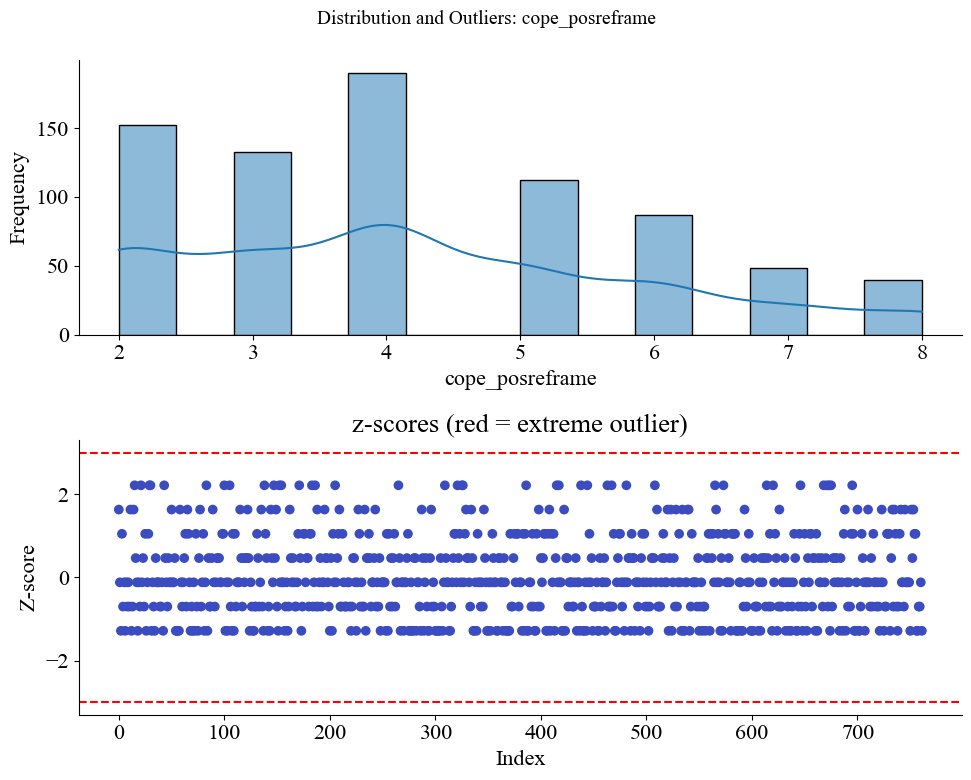

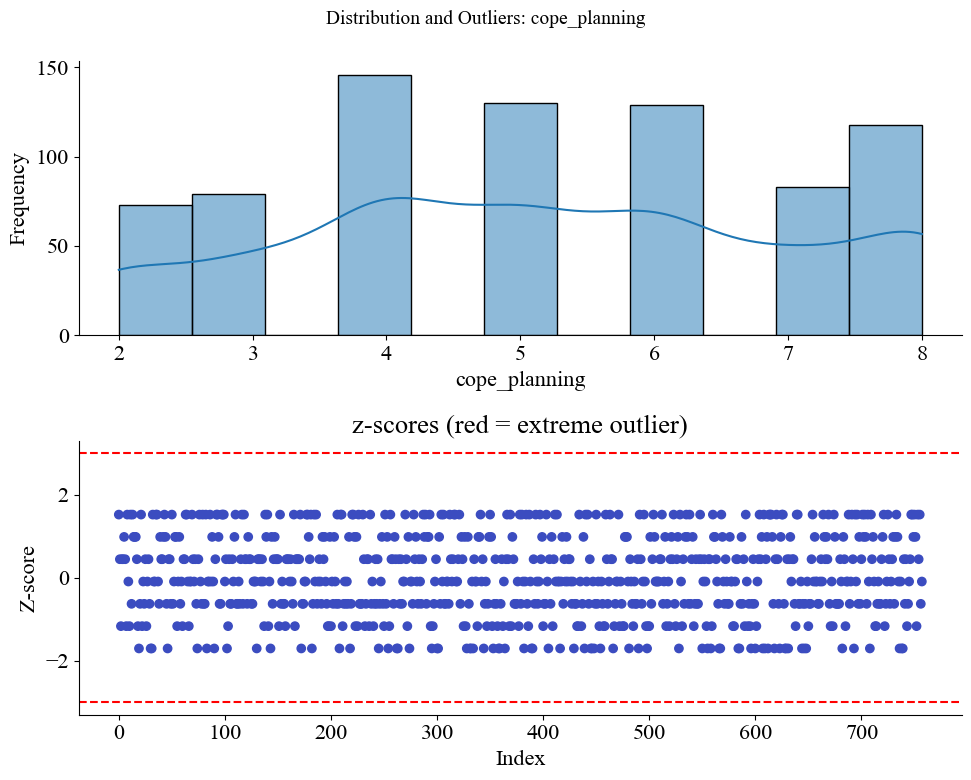

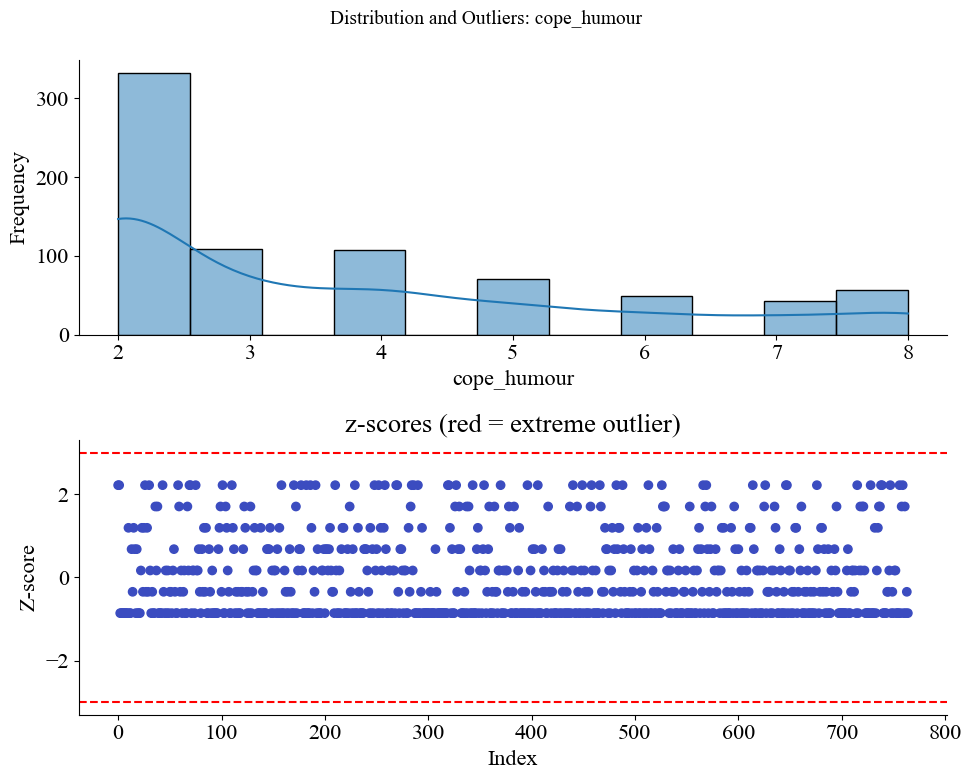

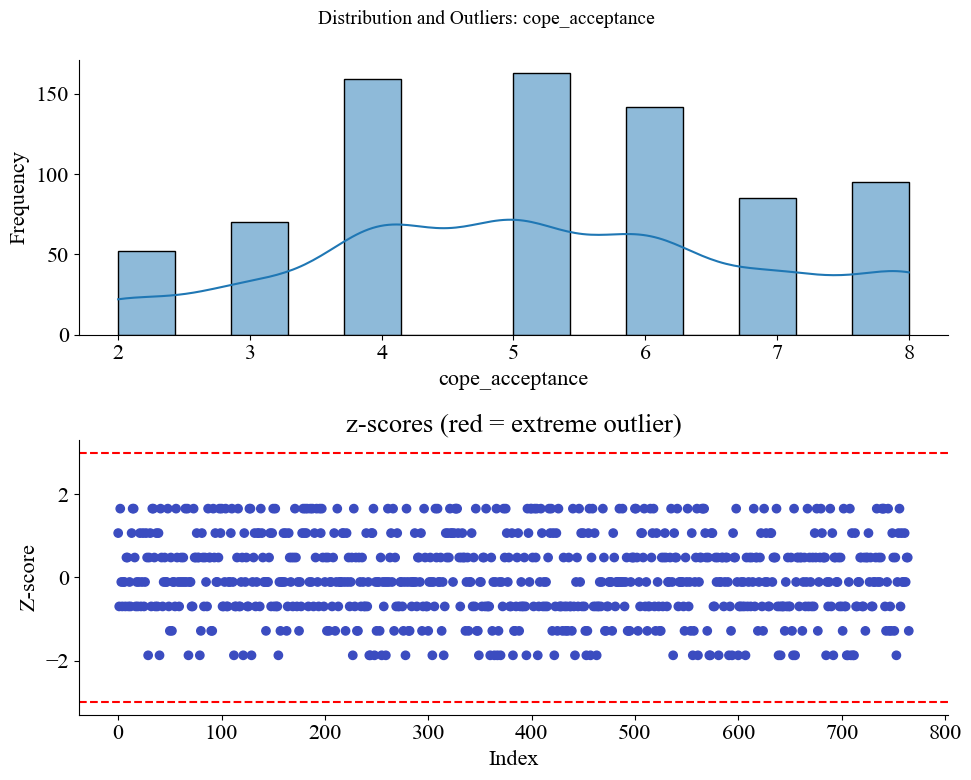

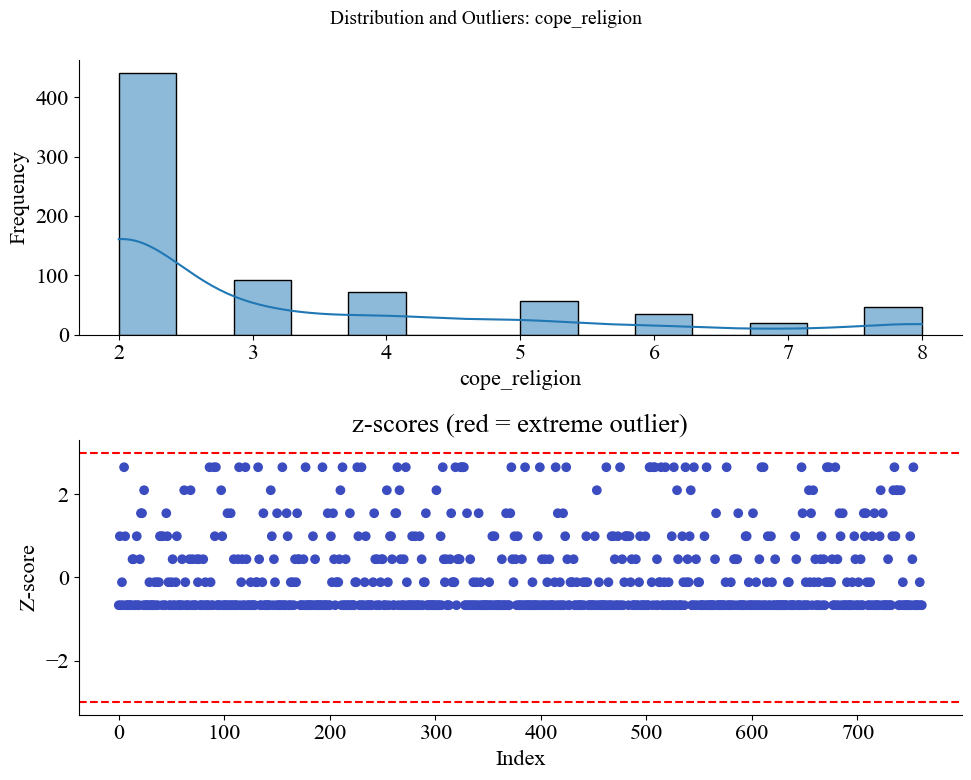

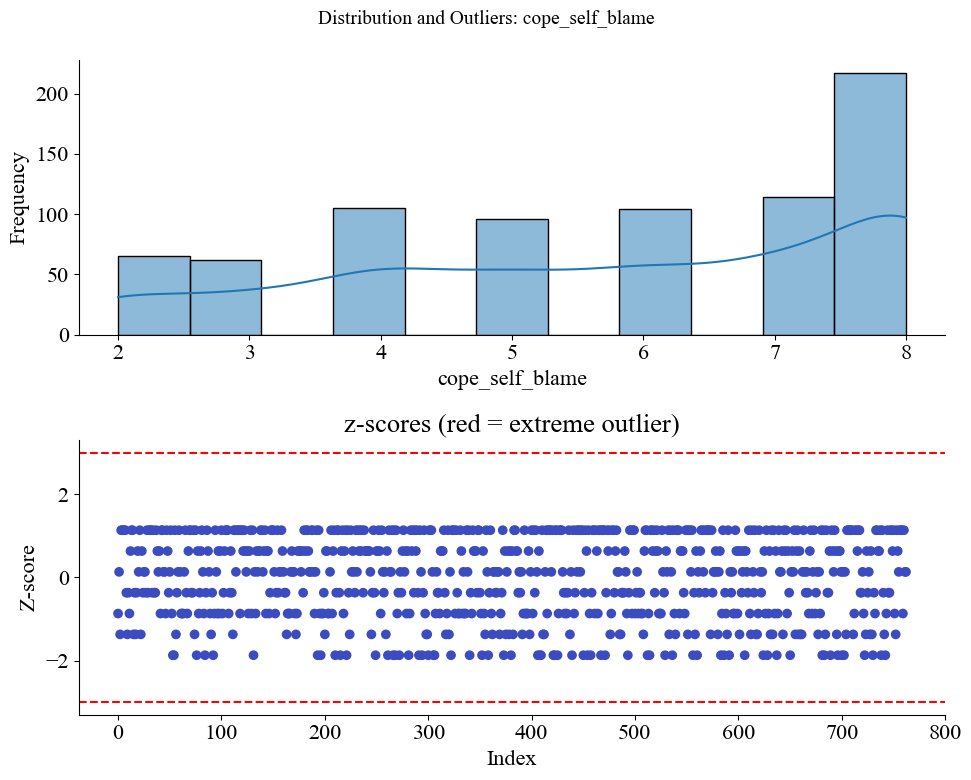

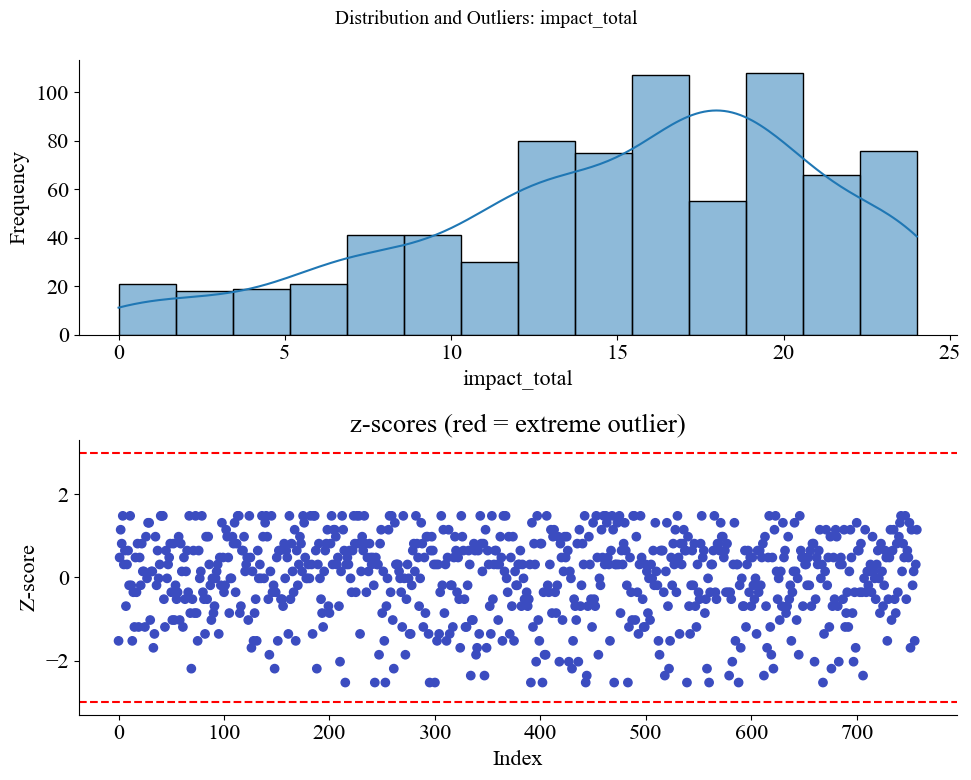

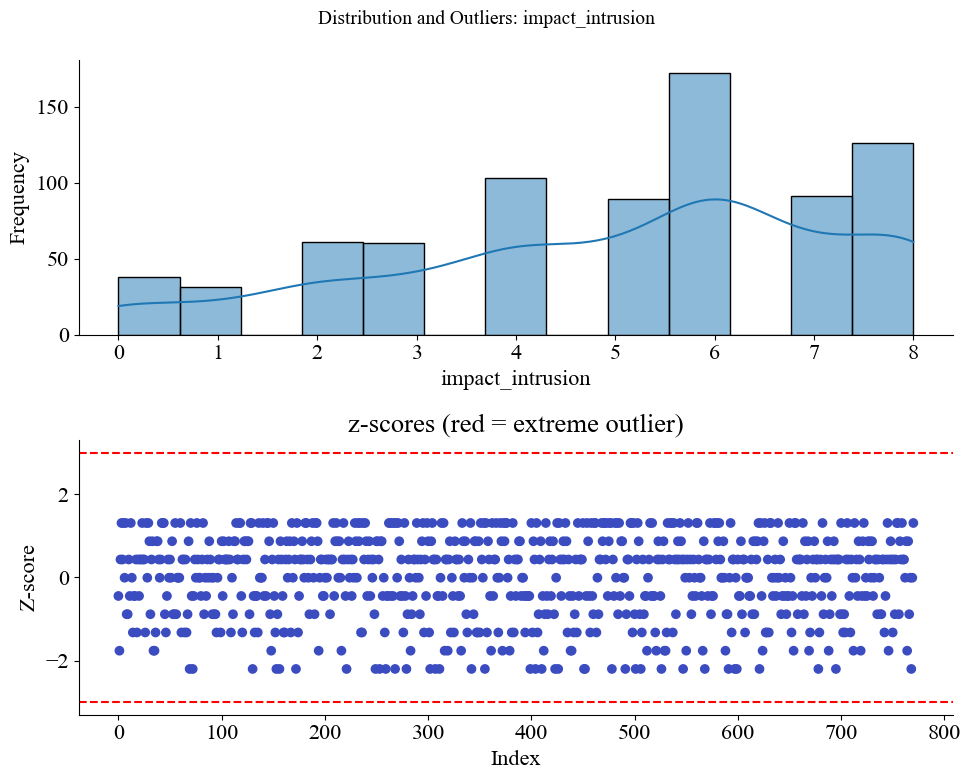

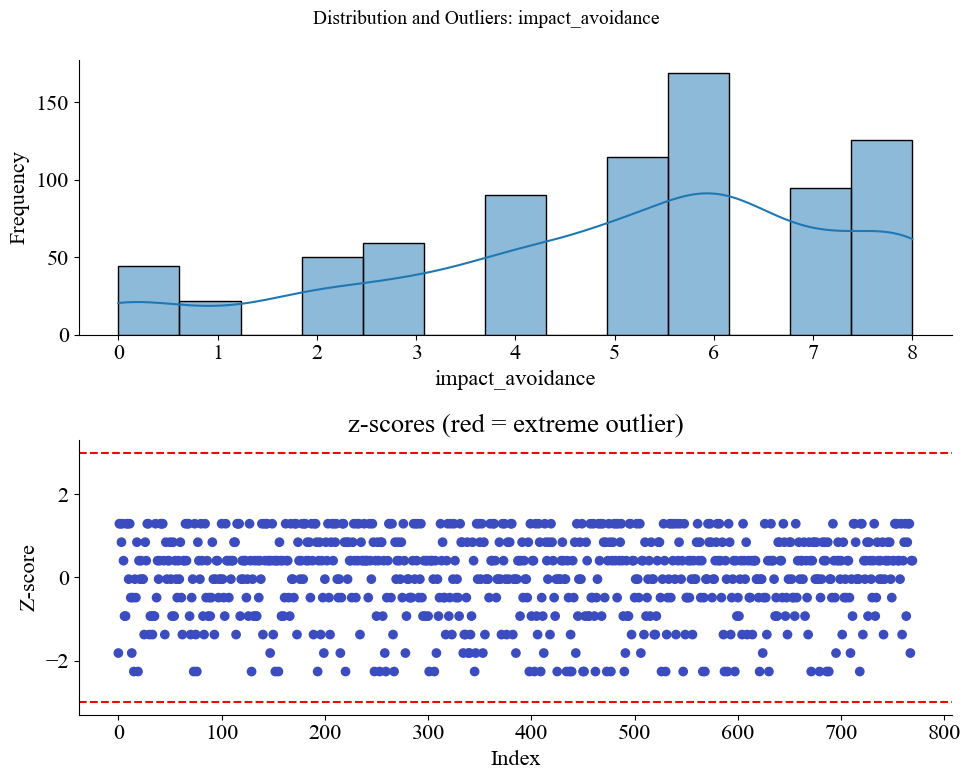

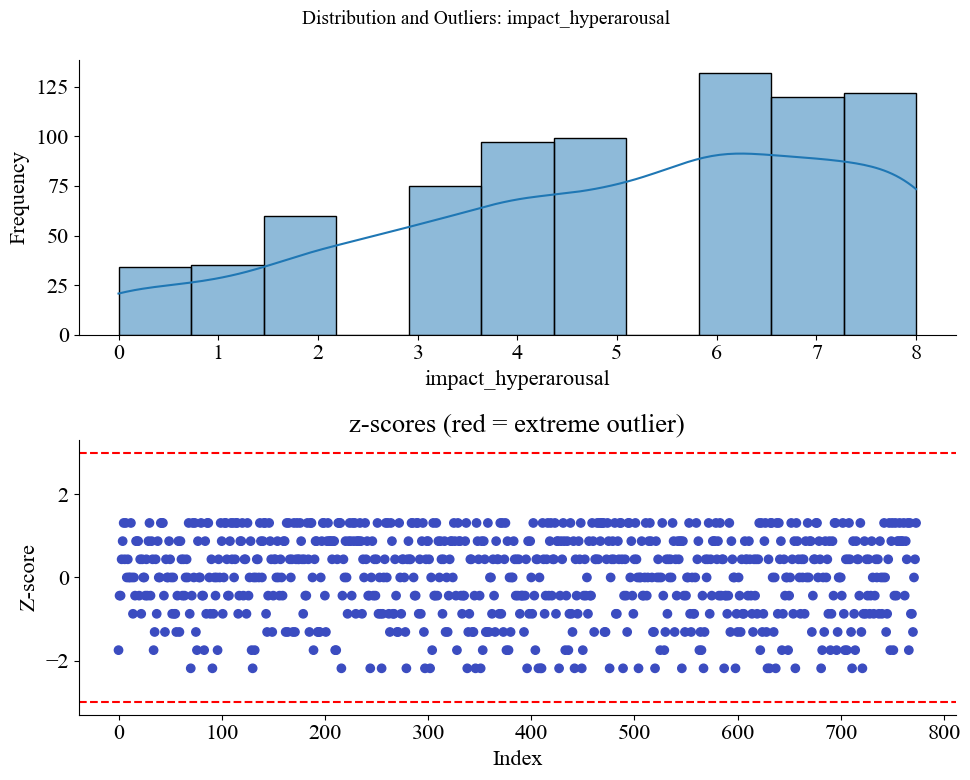

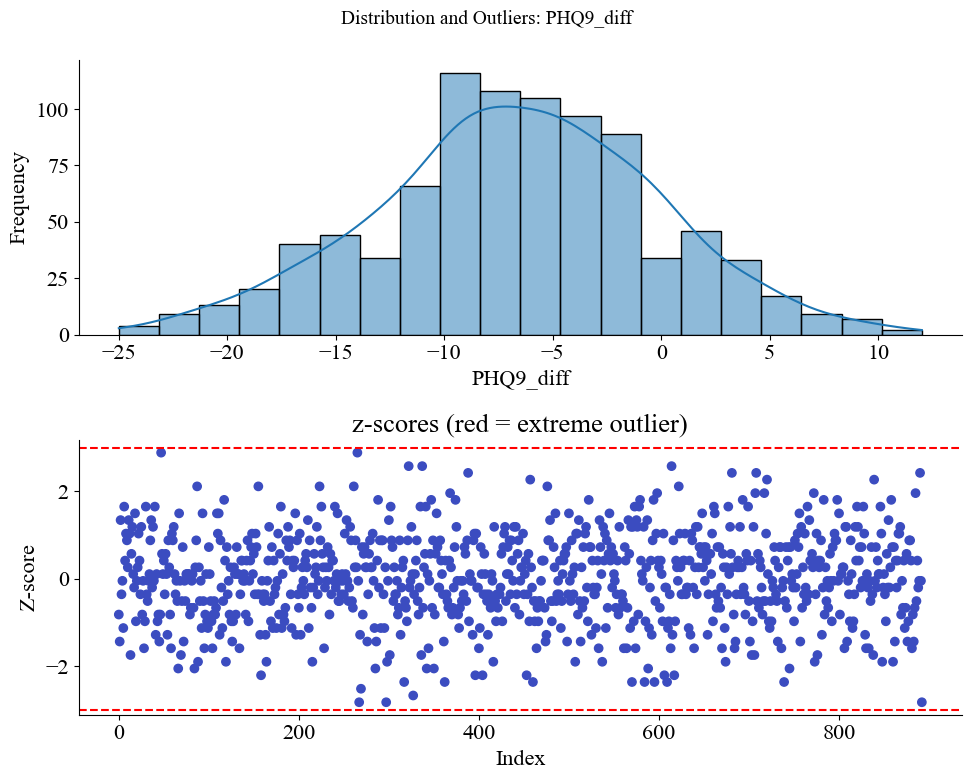

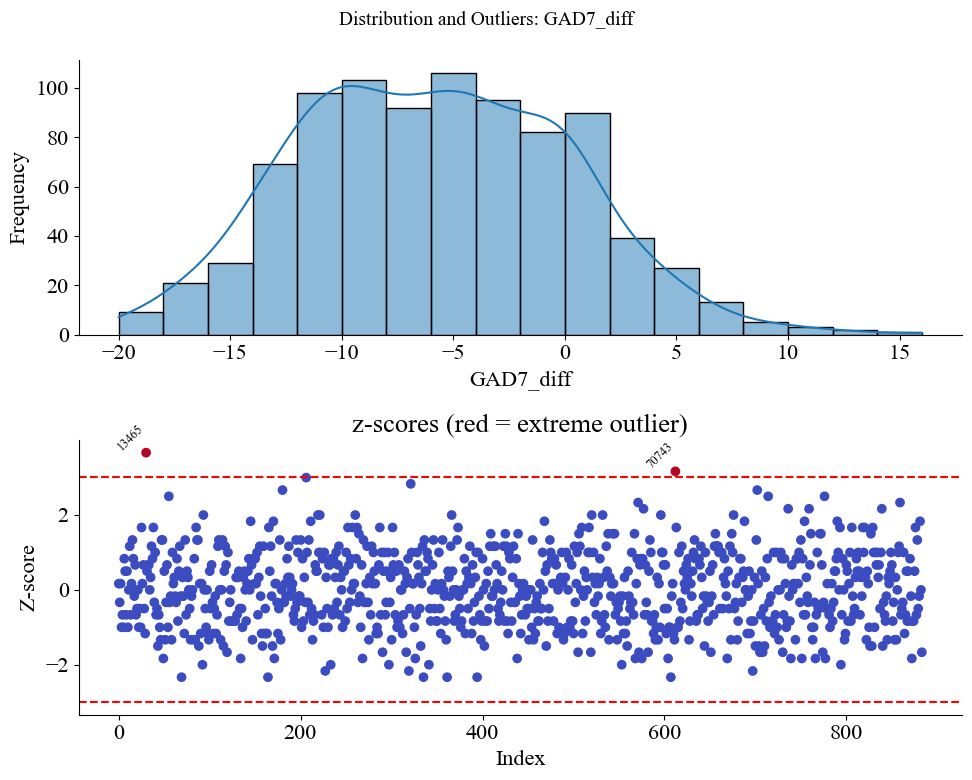

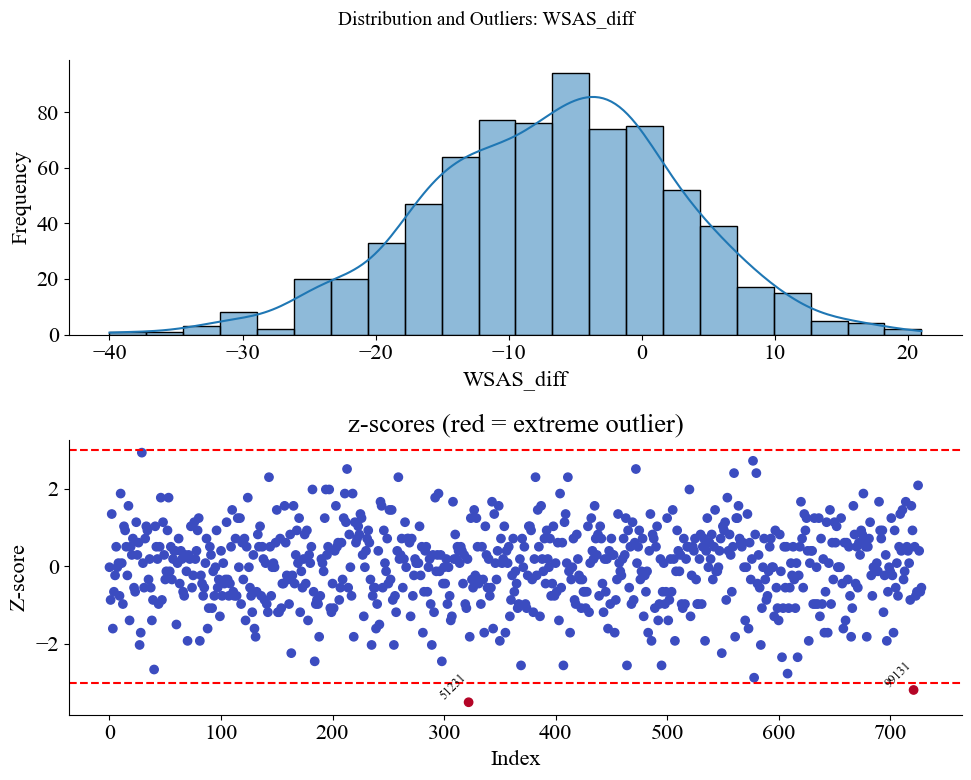

       ID                  Column  Value   Z-score
0   14472  stresslife_total_new.1   20.0  3.513864
1   23875  stresslife_total_new.1   20.0  3.513864
2   40166  stresslife_total_new.1   19.0  3.252598
3   49118  stresslife_total_new.1   19.0  3.252598
4   63502  stresslife_total_new.1   19.0  3.252598
5   19942                 loc_int    4.0 -3.003354
6   24568                 loc_int    4.0 -3.003354
7   30264                 loc_int    3.0 -3.240512
8   39530                 loc_int    3.0 -3.240512
9   88265                 loc_int    1.0 -3.714828
10  11842           pers_emotstab    4.0  3.220272
11  20291           pers_emotstab    4.0  3.220272
12  30156           pers_emotstab    4.0  3.220272
13  32241           pers_emotstab    4.0  3.220272
14  44166           pers_emotstab    4.0  3.220272
15  60871           pers_emotstab    4.0  3.220272
16  67447           pers_emotstab    4.0  3.220272
17  69853           pers_emotstab    4.0  3.220272
18  72729           pers_emotst

In [193]:
outlier_columns = ["PHQ9_pre", "GAD7_pre", "WSAS_pre", "PHQ9_post", "GAD7_post", "WSAS_post", "lonely_total_new","selfcomp_total","resilience_total", 
                   "stresslife_total_new.1", "perc_health_total", "loc_int", "loc_ext", "pers_extraversion", "pers_agreeable", "pers_conscientious", 
                   "pers_emotstab", "pers_openexp", "cope_self_distract", "cope_active", "cope_denial", "cope_substuse", "cope_emotsupp", 
                   "cope_instrsupp", "cope_behavdisengage", "cope_venting", "cope_posreframe", "cope_planning", "cope_humour", "cope_acceptance", 
                   "cope_religion", "cope_self_blame", "impact_total", "impact_intrusion", "impact_avoidance", "impact_hyperarousal", 
                  "PHQ9_diff", "GAD7_diff", "WSAS_diff"]

outlier_track = []

for column in outlier_columns:
    sub_df = df_rr_clean[["ID", column]].dropna()
    data = sub_df[column]
    ids = sub_df["ID"]

    z_scores = zscore(data)
    outliers = abs(z_scores) > 3
    
    for i, outlier2 in enumerate(outliers):
        if outlier2:
            outlier_track.append({
                "ID": ids.iloc[i],
                "Column": column,
                "Value": data.iloc[i],
                "Z-score": z_scores[i]
            })

    fig, axes = plt.subplots(2, 1, figsize=(10, 8))  ## 2 rows, 1 column
    fig.suptitle(f"Distribution and Outliers: {column}", fontsize=14)

    ## Histogram + KDE
    sns.histplot(data, kde=True, ax=axes[0])
    sns.despine()
    axes[0].set_title("")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")

    ## Z-score scatter plot
    axes[1].scatter(range(len(z_scores)), z_scores, c=outliers, cmap="coolwarm")
    axes[1].axhline(3, color="red", linestyle="--")
    axes[1].axhline(-3, color="red", linestyle="--")
    axes[1].set_title("z-scores (red = extreme outlier)")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("Z-score")

    ## Label outliers with ID
    for i, (z, outlier2) in enumerate(zip(z_scores, outliers)):
        if outlier2:
            axes[1].text(i, z, str(ids.iloc[i]), fontsize=9, color="black", 
                         ha="right", va="bottom", rotation=45)
    plt.tight_layout(rect=[0, 0, 1, 1])
    sns.despine()
    plt.show()

outliers_df = pd.DataFrame(outlier_track)
print(outliers_df)

In [194]:
## Remove outliers from columns that will be used in analyses (n=20)
## Don't remove difference in scores because we are not using that for the analysis
ids_remove = [14472, 23875, 40166, 49118, 63502, 19942, 24568, 30264, 39530, 88265, 11842, 20291, 30156, 32241, 44166, 60871,
                 67447, 69853, 72729, 74435]

df_rr_clean_nooutliers = df_rr_clean[~df_rr_clean["ID"].isin(ids_remove)]


## Summary Statistics
Summary statistics were computed before imputing missing data to maintain true dataset characteristics.

### Clinical Variables

In [195]:
phq_pre_count = df_rr_clean_nooutliers["PHQ9_pre"].notna().sum()
gad_pre_count = df_rr_clean_nooutliers["GAD7_pre"].notna().sum()
wsas_pre_count = df_rr_clean_nooutliers["WSAS_pre"].notna().sum()

phq_post_count = df_rr_clean_nooutliers["PHQ9_post"].notna().sum()
gad_post_count = df_rr_clean_nooutliers["GAD7_post"].notna().sum()
wsas_post_count = df_rr_clean_nooutliers["WSAS_post"].notna().sum()
reliable_recovery = df_rr_clean_nooutliers ["rel_recovery"].value_counts()

print (f"{phq_pre_count} completed pre PHQ and {phq_post_count} completed post PHQ")
print (f"{gad_pre_count} completed pre GAD and {gad_post_count} completed post GAD")
print (f"{wsas_pre_count} completed pre WSAS and {wsas_post_count} completed post WSAS")
print (f"Rel Recov {reliable_recovery}")

873 completed pre PHQ and 873 completed post PHQ
873 completed pre GAD and 864 completed post GAD
794 completed pre WSAS and 743 completed post WSAS
Rel Recov rel_recovery
1.0    450
0.0    423
Name: count, dtype: int64


In [196]:
outcome_data = {
    "PHQ9_pre": [
        df_rr_clean_nooutliers["PHQ9_pre"].mean(),
        df_rr_clean_nooutliers["PHQ9_pre"].std()],
    "GAD7_pre": [
        df_rr_clean_nooutliers["GAD7_pre"].mean(),
        df_rr_clean_nooutliers["GAD7_pre"].std()],
    "WSAS_pre": [
        df_rr_clean_nooutliers["WSAS_pre"].mean(),
        df_rr_clean_nooutliers["WSAS_pre"].std()],
    "PHQ9_post": [
        df_rr_clean_nooutliers["PHQ9_post"].mean(),
        df_rr_clean_nooutliers["PHQ9_post"].std()],
    "GAD7_post": [
        df_rr_clean_nooutliers["GAD7_post"].mean(),
        df_rr_clean_nooutliers["GAD7_post"].std()],
    "WSAS_post": [
        df_rr_clean_nooutliers["WSAS_post"].mean(),
        df_rr_clean_nooutliers["WSAS_post"].std()]}

columns = ["Mean", "SD"]

outcome_mean_sd = pd.DataFrame(outcome_data, index=columns)

print(outcome_mean_sd)

       PHQ9_pre   GAD7_pre   WSAS_pre  PHQ9_post  GAD7_post  WSAS_post
Mean  15.939290  14.053837  19.963476   9.279496   8.115741  13.236878
SD     5.419954   4.640823   8.916167   6.690727   5.905437  10.088444


### Sociodemographic

In [197]:
## Ethnicity and recode
ethnicity_counts = df_rr_clean_nooutliers["ethnicity_2"].value_counts(dropna=False)

## Return White or Non-White while keeping NaNs
def categorize_ethnicity (ethnicity):
    if ethnicity == "White":
        return "White"
    elif ethnicity == "NA":
        return np.nan
    else:
        return "Non-White"

df_rr_clean_nooutliers["ethnicity_3"] = df_rr_clean_nooutliers["ethnicity_2"].apply(categorize_ethnicity)

ethnicity_counts_2 = df_rr_clean_nooutliers["ethnicity_3"].value_counts(dropna=False)

## Gender 
gender_counts = df_rr_clean_nooutliers["gender"].value_counts(dropna=False)

## Age and recode 
age_mean = df_rr_clean_nooutliers["age"].mean()
age_sd = df_rr_clean_nooutliers["age"].std()

def categorize_age(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 29:
        return "18-29"
    elif 30 <= age <= 45:
        return "30-45"
    elif 46 <= age <= 64:
        return "46-64"
    else:
        return "65+"
df_rr_clean_nooutliers["age_group1"] = df_rr_clean_nooutliers["age"].apply(categorize_age)

age_counts = df_rr_clean_nooutliers["age_group1"].value_counts(dropna=False)

## Education and recode
education_counts = df_rr_clean_nooutliers["education_level_2"].value_counts(dropna=False)

## Return Further/Higher Education or No/Low Education
def categorize_education(education):
    if pd.isna(education):
        return np.nan
    elif education == "Further education":
        return "Further/Higher Education"
    elif education == "Higher education":
        return "Further/Higher Education"
    else:
        return "No/low education" 
df_rr_clean_nooutliers["education_level_3"] = df_rr_clean_nooutliers["education_level_2"].apply(categorize_education)

education_counts_2 = df_rr_clean_nooutliers["education_level_3"].value_counts(dropna=False)

## Employment and recode
employment_counts = df_rr_clean_nooutliers["employment_status_2"].value_counts(dropna=False)

## Return Employed/Studying, Retired, or Unemployed
def categorize_employment(employment):
    if pd.isna(employment):
        return np.nan
    elif employment == "Employed":
        return "Employed/Studying"
    elif employment == "Full-time student":
        return "Employed/Studying"
    elif employment == "Retired":
        return "Retired"
    else:
        return "Unemployed" 
df_rr_clean_nooutliers["employment_status_3"] = df_rr_clean_nooutliers["employment_status_2"].apply(categorize_employment)

employment_counts_2 = df_rr_clean_nooutliers["employment_status_3"].value_counts(dropna=False)

## Benefits
benefits_counts = df_rr_clean_nooutliers["benefits"].value_counts(dropna=False)

print(f"Ethnicity: {ethnicity_counts}")
print (f"Ethnicity2: {ethnicity_counts_2}")
print(f"Gender: {gender_counts}")
print(f"Age Mean: {age_mean:.2f}")
print(f"Age SD: {age_sd:.2f}")
print(f"Age Counts: {age_counts}")
print(f"Education: {education_counts}")
print(f"Education: {education_counts_2}")
print(f"Employment: {employment_counts}")
print(f"Employment: {employment_counts_2}")
print(f"Benefits: {benefits_counts}")



Ethnicity: ethnicity_2
White                                         798
Mixed or Multiple ethnic groups                27
Asian or Asian British                         21
Black, Black British, Caribbean or African     20
Other ethnic group                              7
Name: count, dtype: int64
Ethnicity2: ethnicity_3
White        798
Non-White     75
Name: count, dtype: int64
Gender: gender
female        629
male          232
non-binary      8
NaN             4
Name: count, dtype: int64
Age Mean: 43.47
Age SD: 16.86
Age Counts: age_group1
46-64    286
30-45    265
18-29    217
65+      105
Name: count, dtype: int64
Education: education_level_2
Further education                                      463
Higher education                                       253
Professional qualifications, e.g. teaching, nursing     86
No formal qualifications                                62
NaN                                                      9
Name: count, dtype: int64
Education: education_le

### Clinical

In [198]:
## Initial problem descriptor and recode
problem_descriptor_all = df_rr_clean_nooutliers["condition_2"].value_counts(dropna=False)

## Return Depression or Anxiety
def categorize_condition (condition):
    if pd.isna(condition):
        return np.nan
    elif condition == "Depression":
        return "Depression"
    else:
        return "Anxiety"

df_rr_clean_nooutliers["condition_clean"] = df_rr_clean_nooutliers["condition_2"].apply(categorize_condition)

problem_descriptor_clean = df_rr_clean_nooutliers["condition_clean"].value_counts(dropna=False)

## Duration of mental health problem and recode

## Return more or less than 12 months
def categorize_duration_mh (duration):
    if pd.isna(duration):
        return np.nan
    elif duration == "More than 12 months":
        return "More than 12 months"
    else:
        return "Less than 12 months"

df_rr_clean_nooutliers["current_mh_duration_clean"] = df_rr_clean_nooutliers["current_mh_duration"].apply(categorize_duration_mh)

duration_all = df_rr_clean_nooutliers["current_mh_duration_clean"].value_counts(dropna=False)

## Recurrence of mental health problem
recurrence_all = df_rr_clean_nooutliers["previous_mh"].value_counts(dropna=False)

## Age of onset category
age_onset_all = df_rr_clean_nooutliers["mh_onset_cat"].value_counts(dropna=False)

## Presence of other MH problems 
other_mh_all = df_rr_clean_nooutliers ["mh_other"].value_counts(dropna=False)

## Presence of physical problems 
physical_health_all = df_rr_clean_nooutliers["physical_problems"].value_counts(dropna=False)

## Psychotropic medications
meds_all = df_rr_clean_nooutliers["mh_meds"].value_counts(dropna=False)

print (f"Problem descriptor: {problem_descriptor_all}")
print (f"Problem descriptor clean: {problem_descriptor_clean}")
print (f"MH Duration: {duration_all}")
print (f"Recurrence: {recurrence_all}")
print (f"Age of Onset: {age_onset_all}")
print (f"Other MH Problem: {other_mh_all}")
print (f"Physical Problem: {physical_health_all}")
print (f"Medication: {meds_all}")

Problem descriptor: condition_2
Depression                               434
GAD                                      199
Post-traumatic stress disorder            79
Adjustment Disorders                      29
Social Anxiety Disorder                   29
Panic disorder                            19
Obsessive compulsive disorder             17
Health Anxiety                            16
Other                                     15
Mixed anxiety and depressive disorder     10
Specific phobia                            8
NaN                                        8
Agoraphobia                                6
Body Dysmorphic Disorder                   4
Name: count, dtype: int64
Problem descriptor clean: condition_clean
Depression    434
Anxiety       431
NaN             8
Name: count, dtype: int64
MH Duration: current_mh_duration_clean
More than 12 months    632
Less than 12 months    229
NaN                     12
Name: count, dtype: int64
Recurrence: previous_mh
Yes    655
No     12

### Psychosocial

In [199]:
## Compassion and subscales 
compassion_all_mean = df_rr_clean_nooutliers["selfcomp_total"].mean()
compassion_all_sd = df_rr_clean_nooutliers["selfcomp_total"].std()
compassion_all_na = df_rr_clean_nooutliers["selfcomp_total"].isna().sum()

print (f"Missing compassion: {compassion_all_na}, Average: {compassion_all_mean:.2f} SD: {compassion_all_sd:.2f}")

compassion_suffer_mean = df_rr_clean_nooutliers["sc_recsuffer"].mean()
compassion_suffer_sd = df_rr_clean_nooutliers["sc_recsuffer"].std()
compassion_suffer_na = df_rr_clean_nooutliers["sc_recsuffer"].isna().sum()

print (f"Missing sc suffer: {compassion_suffer_na}, Average: {compassion_suffer_mean:.2f} SD: {compassion_suffer_sd:.2f}")

compassion_univ_mean = df_rr_clean_nooutliers["sc_universality"].mean()
compassion_univ_sd = df_rr_clean_nooutliers["sc_universality"].std()
compassion_univ_na = df_rr_clean_nooutliers["sc_universality"].isna().sum()

print (f"Missing sc universality: {compassion_univ_na}, Average: {compassion_univ_mean:.2f} SD: {compassion_univ_sd:.2f}")

compassion_feeling_mean = df_rr_clean_nooutliers["sc_feeling"].mean()
compassion_feeling_sd = df_rr_clean_nooutliers["sc_feeling"].std()
compassion_feeling_na = df_rr_clean_nooutliers["sc_feeling"].isna().sum()

print (f"Missing sc feeling: {compassion_feeling_na}, Average: {compassion_feeling_mean:.2f} SD: {compassion_feeling_sd:.2f}")

compassion_tolerance_mean = df_rr_clean_nooutliers["sc_tolerance"].mean()
compassion_tolerance_sd = df_rr_clean_nooutliers["sc_tolerance"].std()
compassion_tolerance_na = df_rr_clean_nooutliers["sc_tolerance"].isna().sum()

print (f"Missing sc tolerance: {compassion_tolerance_na}, Average: {compassion_tolerance_mean:.2f} SD: {compassion_tolerance_sd:.2f}")

compassion_action_mean = df_rr_clean_nooutliers["sc_action"].mean()
compassion_action_sd = df_rr_clean_nooutliers["sc_action"].std()
compassion_action_na = df_rr_clean_nooutliers["sc_action"].isna().sum()

print (f"Missing sc action: {compassion_action_na}, Average: {compassion_action_mean:.2f} SD: {compassion_action_sd:.2f}")

## Loneliness
loneliness_all_mean = df_rr_clean_nooutliers["lonely_total_new"].mean()
loneliness_all_sd = df_rr_clean_nooutliers["lonely_total_new"].std()
loneliness_all_na = df_rr_clean_nooutliers["lonely_total_new"].isna().sum()

print (f"Missing loneliness: {loneliness_all_na}, Average: {loneliness_all_mean:.2f} SD: {loneliness_all_sd:.2f}")

## Perceived Health
perceived_health_all_mean = df_rr_clean_nooutliers["perc_health_total"].mean()
perceived_health_all_sd = df_rr_clean_nooutliers["perc_health_total"].std()
perceived_health_all_na = df_rr_clean_nooutliers["perc_health_total"].isna().sum()

print (f"Missing Perceived Health: {perceived_health_all_na}, Average: {perceived_health_all_mean:.2f} SD: {perceived_health_all_sd:.2f}")

## Resilience
resilience_all_mean = df_rr_clean_nooutliers["resilience_total"].mean()
resilience_all_sd = df_rr_clean_nooutliers["resilience_total"].std()
resilience_all_na = df_rr_clean_nooutliers["resilience_total"].isna().sum()

print (f"Missing Resilience: {resilience_all_na}, Average: {resilience_all_mean:.2f} SD: {resilience_all_sd:.2f}")

## Internal LOC
loc_int_all_mean = df_rr_clean_nooutliers["loc_int"].mean()
loc_int_all_sd = df_rr_clean_nooutliers["loc_int"].std()
loc_int_all_na = df_rr_clean_nooutliers["loc_int"].isna().sum()

print (f"Locus Int: {loc_int_all_na}, Average: {loc_int_all_mean:.2f} SD: {loc_int_all_sd:.2f}")

## External LOC
loc_ext_all_mean = df_rr_clean_nooutliers["loc_ext"].mean()
loc_ext_all_sd = df_rr_clean_nooutliers["loc_ext"].std()
loc_ext_all_na = df_rr_clean_nooutliers["loc_ext"].isna().sum()

print (f"Locus Ext: {loc_ext_all_na}, Average: {loc_ext_all_mean:.2f} SD: {loc_ext_all_sd:.2f}")

## Personality types
personality_extraversion_all_mean = df_rr_clean_nooutliers["pers_extraversion"].mean()
personality_extraversion_all_sd = df_rr_clean_nooutliers["pers_extraversion"].std()
personality_extraversion_all_na = df_rr_clean_nooutliers["pers_extraversion"].isna().sum()

print (f"Pers Extraversion: {personality_extraversion_all_na}, Average: {personality_extraversion_all_mean:.2f} SD: {personality_extraversion_all_sd:.2f}")

personality_agreeableness_all_mean = df_rr_clean_nooutliers["pers_agreeable"].mean()
personality_agreeableness_all_std = df_rr_clean_nooutliers["pers_agreeable"].std()
personality_agreeableness_all_na = df_rr_clean_nooutliers["pers_agreeable"].isna().sum()

print (f"Pers Agreeableness: {personality_agreeableness_all_na}, Average: {personality_agreeableness_all_mean:.2f} SD: {personality_agreeableness_all_std:.2f}")

personality_conscien_all_mean = df_rr_clean_nooutliers["pers_conscientious"].mean()
personality_conscien_all_sd = df_rr_clean_nooutliers["pers_conscientious"].std()
personality_conscien_all_na = df_rr_clean_nooutliers["pers_conscientious"].isna().sum()

print (f"Pers Conscien: {personality_conscien_all_na}, Average: {personality_conscien_all_mean:.2f} SD: {personality_conscien_all_sd:.2f}")

personality_emotional_all_mean = df_rr_clean_nooutliers["pers_emotstab"].mean()
personality_emotional_all_sd = df_rr_clean_nooutliers["pers_emotstab"].std()
personality_emotional_all_na = df_rr_clean_nooutliers["pers_emotstab"].isna().sum()

print (f"Pers Emotional: {personality_emotional_all_na}, Average: {personality_emotional_all_mean:.2f} SD: {personality_emotional_all_sd:.2f}")

personality_open_all_mean = df_rr_clean_nooutliers["pers_openexp"].mean()
personality_open_all_sd = df_rr_clean_nooutliers["pers_openexp"].std()
personality_open_all_na = df_rr_clean_nooutliers["pers_openexp"].isna().sum()

print (f"Pers Open: {personality_open_all_na}, Average: {personality_open_all_mean:.2f} SD: {personality_open_all_sd:.2f}")

## Stress events
stressful_life_events_all_mean = df_rr_clean_nooutliers["stresslife_total_new.1"].mean()
stressful_life_events_all_sd = df_rr_clean_nooutliers["stresslife_total_new.1"].std()
stressful_life_events_all_na = df_rr_clean_nooutliers["stresslife_total_new.1"].isna().sum()

print (f"Stress event: {stressful_life_events_all_na}, Average: {stressful_life_events_all_mean:.2f} SD: {stressful_life_events_all_sd:.2f}")

## Impact of events and subscales
impact_of_event_all_mean = df_rr_clean_nooutliers["impact_total"].mean()
impact_of_event_all_sd = df_rr_clean_nooutliers["impact_total"].std()
impact_of_event_all_na = df_rr_clean_nooutliers["impact_total"].isna().sum()

print (f"Impact: {impact_of_event_all_na}, Average: {impact_of_event_all_mean:.2f} SD: {impact_of_event_all_sd:.2f}")

impact_of_event_intru_mean = df_rr_clean_nooutliers["impact_intrusion"].mean()
impact_of_event_intru_sd = df_rr_clean_nooutliers["impact_intrusion"].std()
impact_of_event_intru_na = df_rr_clean_nooutliers["impact_intrusion"].isna().sum()

print (f"impact_intrusion: {impact_of_event_intru_na}, Average: {impact_of_event_intru_mean:.2f} SD: {impact_of_event_intru_sd:.2f}")

impact_of_event_avoid_mean = df_rr_clean_nooutliers["impact_avoidance"].mean()
impact_of_event_avoid_sd = df_rr_clean_nooutliers["impact_avoidance"].std()
impact_of_event_avoid_na = df_rr_clean_nooutliers["impact_avoidance"].isna().sum()

print (f"impact_avoidance: {impact_of_event_avoid_na}, Average: {impact_of_event_avoid_mean:.2f} SD: {impact_of_event_avoid_sd:.2f}")

impact_of_event_hypera_mean = df_rr_clean_nooutliers["impact_hyperarousal"].mean()
impact_of_event_hypera_sd = df_rr_clean_nooutliers["impact_hyperarousal"].std()
impact_of_event_hypera_na = df_rr_clean_nooutliers["impact_hyperarousal"].isna().sum()

print (f"impact_hyperarousal: {impact_of_event_hypera_na}, Average: {impact_of_event_hypera_mean:.2f} SD: {impact_of_event_hypera_sd:.2f}")

## Coping styles
coping_selfdis_all_mean = df_rr_clean_nooutliers["cope_self_distract"].mean()
coping_selfdis_all_sd = df_rr_clean_nooutliers["cope_self_distract"].std()
coping_selfdis_all_na = df_rr_clean_nooutliers["cope_self_distract"].isna().sum()

print (f"Coping Selfdis: {coping_selfdis_all_na}, Average: {coping_selfdis_all_mean:.2f} SD: {coping_selfdis_all_sd:.2f}")

coping_active_all_mean = df_rr_clean_nooutliers["cope_active"].mean()
coping_active_all_sd = df_rr_clean_nooutliers["cope_active"].std()
coping_active_all_na = df_rr_clean_nooutliers["cope_active"].isna().sum()

print (f"Coping Active: {coping_active_all_na}, Average: {coping_active_all_mean:.2f} SD: {coping_active_all_sd:.2f}")

coping_denial_all_mean = df_rr_clean_nooutliers["cope_denial"].mean()
coping_denial_all_sd = df_rr_clean_nooutliers["cope_denial"].std()
coping_denial_all_na = df_rr_clean_nooutliers["cope_denial"].isna().sum()

print (f"Coping Denial: {coping_denial_all_na}, Average: {coping_denial_all_mean:.2f} SD: {coping_denial_all_sd:.2f}")

coping_substance_all_mean = df_rr_clean_nooutliers["cope_substuse"].mean()
coping_substance_all_sd = df_rr_clean_nooutliers["cope_substuse"].std()
coping_substance_all_na = df_rr_clean_nooutliers["cope_substuse"].isna().sum()

print (f"Coping Substance: {coping_substance_all_na}, Average: {coping_substance_all_mean:.2f} SD: {coping_substance_all_sd:.2f}")

coping_emotional_all_mean = df_rr_clean_nooutliers["cope_emotsupp"].mean()
coping_emotional_all_sd = df_rr_clean_nooutliers["cope_emotsupp"].std()
coping_emotional_all_na = df_rr_clean_nooutliers["cope_emotsupp"].isna().sum()

print (f"Coping emotional: {coping_emotional_all_na}, Average: {coping_emotional_all_mean:.2f} SD: {coping_emotional_all_sd:.2f}")

coping_instrumental_all_mean = df_rr_clean_nooutliers["cope_instrsupp"].mean()
coping_instrumental_all_sd = df_rr_clean_nooutliers["cope_instrsupp"].std()
coping_instrumental_all_na = df_rr_clean_nooutliers["cope_instrsupp"].isna().sum()

print (f"Coping Instrumental: {coping_instrumental_all_na}, Average: {coping_instrumental_all_mean:.2f} SD: {coping_instrumental_all_sd:.2f}")

coping_behav_all_mean = df_rr_clean_nooutliers["cope_behavdisengage"].mean()
coping_behav_all_sd = df_rr_clean_nooutliers["cope_behavdisengage"].std()
coping_behav_all_na = df_rr_clean_nooutliers["cope_behavdisengage"].isna().sum()

print (f"Coping Behav: {coping_behav_all_na}, Average: {coping_behav_all_mean:.2f} SD: {coping_behav_all_sd:.2f}")

coping_vent_all_mean = df_rr_clean_nooutliers["cope_venting"].mean()
coping_vent_all_sd = df_rr_clean_nooutliers["cope_venting"].std()
coping_vent_all_na = df_rr_clean_nooutliers["cope_venting"].isna().sum()

print (f"Coping Vent: {coping_vent_all_na}, Average: {coping_vent_all_mean:.2f} SD: {coping_vent_all_sd:.2f}")

coping_positive_all_mean = df_rr_clean_nooutliers["cope_posreframe"].mean()
coping_positive_all_sd = df_rr_clean_nooutliers["cope_posreframe"].std()
coping_positive_all_na = df_rr_clean_nooutliers["cope_posreframe"].isna().sum()

print (f"Coping positive: {coping_positive_all_na}, Average: {coping_positive_all_mean:.2f} SD: {coping_positive_all_sd:.2f}")

coping_planning_all_mean = df_rr_clean_nooutliers["cope_planning"].mean()
coping_planning_all_sd = df_rr_clean_nooutliers["cope_planning"].std()
coping_planning_all_na = df_rr_clean_nooutliers["cope_planning"].isna().sum()

print (f"Coping planning: {coping_planning_all_na}, Average: {coping_planning_all_mean:.2f} SD: {coping_planning_all_sd:.2f}")

coping_humour_all_mean = df_rr_clean_nooutliers["cope_humour"].mean()
coping_humour_all_sd = df_rr_clean_nooutliers["cope_humour"].std()
coping_humour_all_na = df_rr_clean_nooutliers["cope_humour"].isna().sum()

print (f"Coping humour: {coping_humour_all_na}, Average: {coping_humour_all_mean:.2f} SD: {coping_humour_all_sd:.2f}")

coping_acceptance_all_mean = df_rr_clean_nooutliers["cope_acceptance"].mean()
coping_acceptance_all_sd = df_rr_clean_nooutliers["cope_acceptance"].std()
coping_acceptance_all_na = df_rr_clean_nooutliers["cope_acceptance"].isna().sum()

print (f"Coping acceptance: {coping_acceptance_all_na}, Average: {coping_acceptance_all_mean:.2f} SD: {coping_acceptance_all_sd:.2f}")

coping_religion_all_mean = df_rr_clean_nooutliers["cope_religion"].mean()
coping_religion_all_sd = df_rr_clean_nooutliers["cope_religion"].std()
coping_religion_all_na = df_rr_clean_nooutliers["cope_religion"].isna().sum()

print (f"Coping religion: {coping_religion_all_na}, Average: {coping_religion_all_mean:.2f} SD: {coping_religion_all_sd:.2f}")

coping_self_blame_all_mean = df_rr_clean_nooutliers["cope_self_blame"].mean()
coping_self_blame_all_sd = df_rr_clean_nooutliers["cope_self_blame"].std()
coping_self_blame_all_na = df_rr_clean_nooutliers["cope_self_blame"].isna().sum()

print (f"Coping Self Blame: {coping_self_blame_all_na}, Average: {coping_self_blame_all_mean:.2f} SD: {coping_self_blame_all_sd:.2f}")


Missing compassion: 76, Average: 59.92 SD: 13.37
Missing sc suffer: 63, Average: 13.90 SD: 3.62
Missing sc universality: 65, Average: 16.75 SD: 3.03
Missing sc feeling: 63, Average: 9.42 SD: 3.49
Missing sc tolerance: 68, Average: 9.26 SD: 3.30
Missing sc action: 67, Average: 10.64 SD: 3.73
Missing loneliness: 19, Average: 6.55 SD: 1.91
Missing Perceived Health: 26, Average: 8.80 SD: 4.91
Missing Resilience: 77, Average: 28.58 SD: 7.68
Locus Int: 36, Average: 16.73 SD: 4.09
Locus Ext: 37, Average: 14.90 SD: 7.27
Pers Extraversion: 35, Average: 1.59 SD: 1.13
Pers Agreeableness: 36, Average: 2.60 SD: 0.93
Pers Conscien: 35, Average: 2.59 SD: 1.05
Pers Emotional: 34, Average: 1.04 SD: 0.86
Pers Open: 34, Average: 2.43 SD: 0.93
Stress event: 82, Average: 6.46 SD: 3.72
Impact: 134, Average: 15.20 SD: 5.96
impact_intrusion: 121, Average: 5.04 SD: 2.26
impact_avoidance: 122, Average: 5.11 SD: 2.24
impact_hyperarousal: 118, Average: 5.03 SD: 2.27
Coping Selfdis: 127, Average: 5.31 SD: 1.79
Cop

### Figures

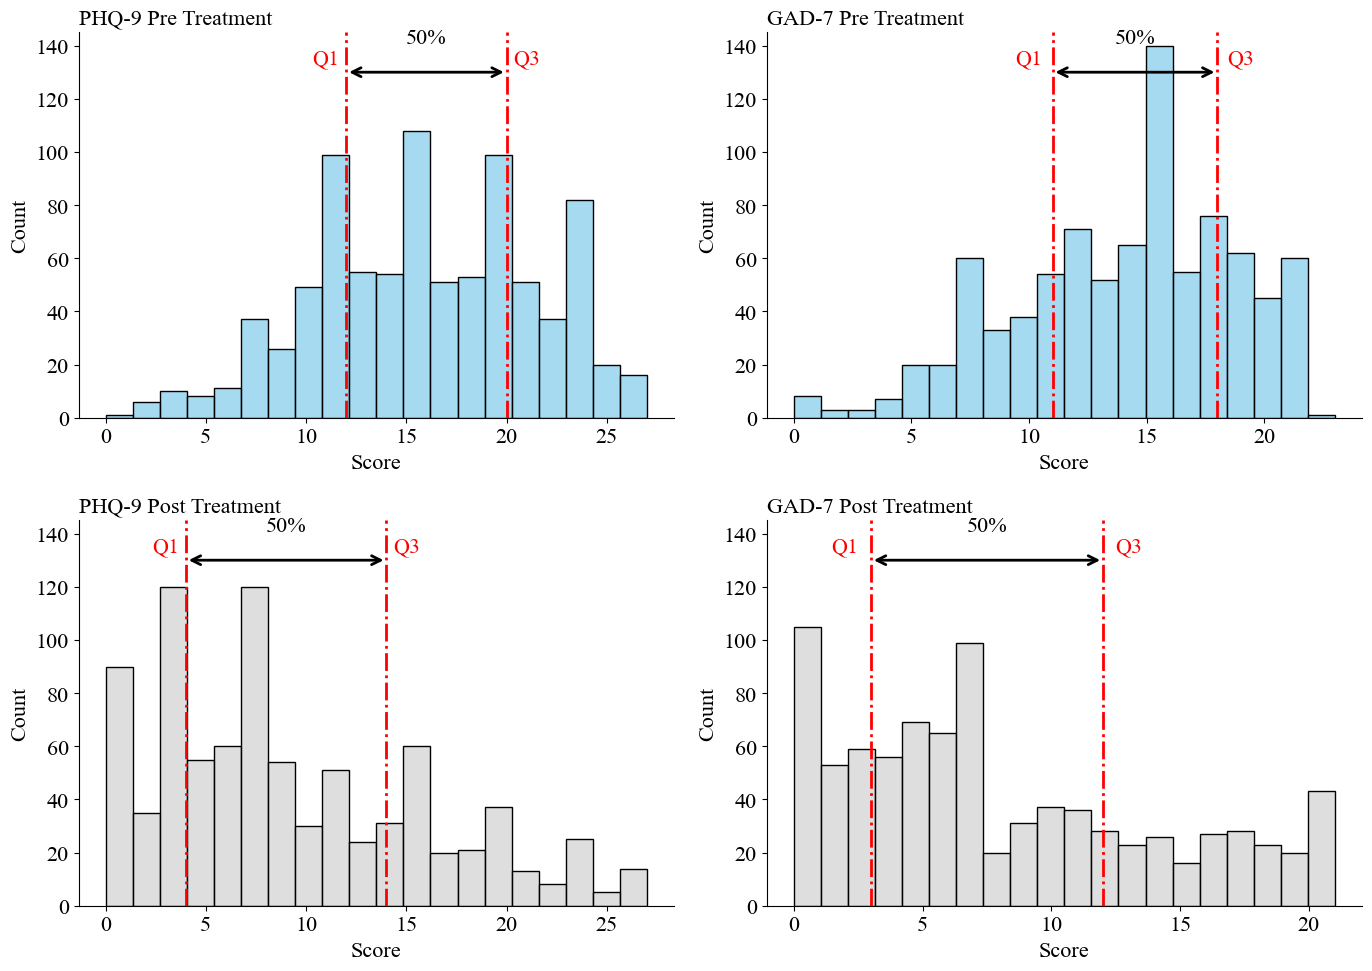

In [200]:
measures = ["PHQ9", "GAD7"]
timepoints = ["pre", "post"]

## Define colors for pre and post
timepoint_colors = {"pre": "skyblue", "post": "lightgrey"}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))  # 2x2 since you have 4 plots
axes = axes.flatten()

## Titles of plots
custom_titles = ["PHQ-9 Pre Treatment", "GAD-7 Pre Treatment", "PHQ-9 Post Treatment", "GAD-7 Post Treatment"]

for index in range(4):
    measure = measures[index % 2] ## distinguish between PHQ and GAD
    timepoint = "pre" if index < 2 else "post" ## specify time point
    col = f"{measure}_{timepoint}" ## put them together 
    scores = df_rr_clean_nooutliers[col].dropna()

    ## Calculate quartiles
    q1 = scores.quantile(0.25)
    q3 = scores.quantile(0.75)

    sns.histplot(scores, bins=20, ax=axes[index], color=timepoint_colors[timepoint])
    axes[index].set_ylim(0, 145)
    axes[index].set_title(custom_titles[index], x=0, ha="left", fontsize=16)
    axes[index].set_xlabel("Score")
    axes[index].set_ylabel("Count")
    axes[index].axvline(q1, color="red", lw=2, ls="-.", label="Q1 (25%)")
    axes[index].axvline(q3, color="red", lw=2, ls="-.", label="Q3 (75%)")
    axes[index].annotate(
        "", xy=(q1, 130), xycoords="data", xytext=(q3, 130), textcoords="data",
        arrowprops={"arrowstyle": "<->", "lw": 2, "color": "black"}
    )
    axes[index].annotate("Q1", xy=(q1, 10), xycoords="data",
                          xytext=(q1-1, 135),
                          textcoords="data", ha="center", va="center", fontsize=16, color="red")

    axes[index].annotate("Q3", xy=(q3, 10), xycoords="data",
                          xytext=(q3+1, 135),
                          textcoords="data", ha="center", va="center", fontsize=16, color="red")

    mid_point = (q1 + q3) / 2
    axes[index].annotate("50%", xy=(mid_point, 143),
                          xycoords="data", ha="center", va="center", fontsize=16, color="black")

    sns.despine(ax=axes[index])

plt.tight_layout()
plt.savefig("pre-postMH.png", dpi=300, bbox_inches="tight")
plt.show()

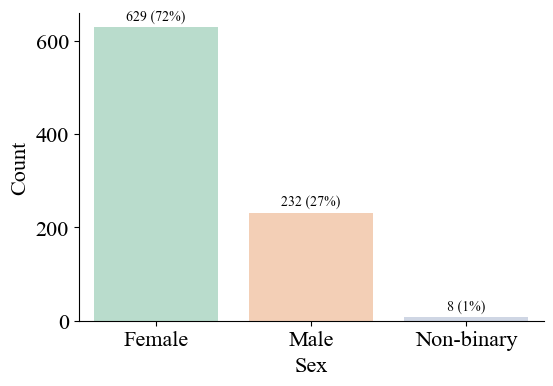

In [201]:
## Gender 
gender_labels = {0: "Male", 1: "Female", 2: "Non-binary"} 
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_rr_clean_nooutliers, x="gender", palette="Pastel2")

## Females then males
## Replace original labels 
ax.set_xticks([1, 0, 2])
ax.set_xticklabels([gender_labels.get(tick, "original") for tick in [0, 1, 2]])

## Counts and percentages
total = len(df_rr_clean_nooutliers)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.text(p.get_x() + p.get_width() / 2,
            p.get_height() + total * 0.01,
            f"{count} ({percentage:.0f}%)",
            ha="center", va="bottom", fontsize=10)

plt.xlabel("Sex")
plt.ylabel("Count")
sns.despine(ax=ax) 
plt.savefig("gender.png", dpi=300, bbox_inches="tight")
plt.show()


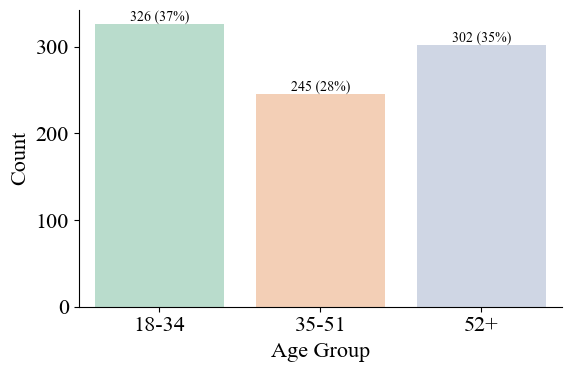

In [202]:
## Change age groups to tertiles (from moderation)
def assign_tertile(age):
    if age < 34.96:
        return 0
    elif age < 51.81:
        return 1
    else:
        return 2

df_rr_clean_nooutliers["age_tertile"] = df_rr_clean_nooutliers["age"].apply(assign_tertile)

age_tertile_labels = {
    0: "18-34",
    1: "35-51",
    2: "52+"
}
df_rr_clean_nooutliers["age_tertile_label"] = df_rr_clean_nooutliers["age_tertile"].map(age_tertile_labels)

## Plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df_rr_clean_nooutliers,
    x="age_tertile_label",
    palette="Pastel2",
    order=["18-34", "35-51", "52+"]
)
plt.xlabel("Age Group")
plt.ylabel("Count")
sns.despine(ax=ax)

total = len(df_rr_clean_nooutliers)
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    label = f"{count} ({percentage:.0f}%)"
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom',
                fontsize=10)

plt.tight_layout()
plt.savefig("age_groups_2.png", dpi=300, bbox_inches="tight")
plt.show()

GAD: 0.00
PHQ: 0.00


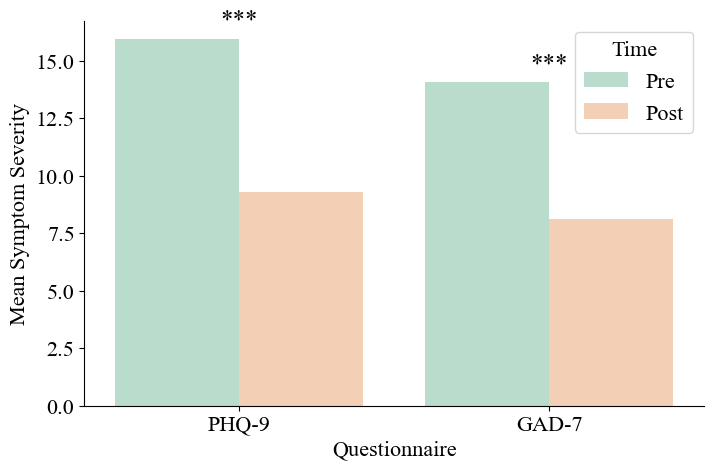

In [203]:
## Difference in outcome scores 

## Get rid of NaNs first in GAD7
pre = df_rr_clean_nooutliers["GAD7_pre"]
post = df_rr_clean_nooutliers["GAD7_post"]

## Drop nans
nan_mask = ~np.isnan(pre) & ~np.isnan(post)
pre_clean = pre[nan_mask]
post_clean = post[nan_mask]

## t-test
gad_t_value, gad_p_value = ttest_rel(pre_clean, post_clean)
phq_t_value, phq_p_value = ttest_rel(df_rr_clean_nooutliers["PHQ9_pre"], df_rr_clean_nooutliers["PHQ9_post"])
print (f"GAD: {gad_p_value:.2f}")
print (f"PHQ: {phq_p_value:.2f}")

pre_post_means = pd.DataFrame({
    "PHQ-9": [df_rr_clean_nooutliers["PHQ9_pre"].mean(), df_rr_clean_nooutliers["PHQ9_post"].mean()],
    "GAD-7": [df_rr_clean_nooutliers["GAD7_pre"].mean(), df_rr_clean_nooutliers["GAD7_post"].mean()]
}, index=["Pre", "Post"])

## Transpose to plot
df_melted = pre_post_means.T.reset_index().melt(id_vars="index", var_name="Time", value_name="Mean Score")
df_melted.rename(columns={"index": "Questionnaire"}, inplace=True)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=df_melted, x="Questionnaire", y="Mean Score", hue="Time", palette="Pastel2")
plt.title("")
plt.ylabel("Mean Symptom Severity")

def significance_test(p_val):
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    else:
        return "Not Significant" 

for i, measure in enumerate(["PHQ-9", "GAD-7"]):
    if measure == "PHQ-9":
        pval = phq_p_value
    else:
        pval = gad_p_value
    ## Place significance
    bar_heights = df_melted[df_melted["Questionnaire"] == measure]["Mean Score"]
    y = bar_heights.max() + 0.5
    ax.annotate(significance_test(pval), 
                xy=(i, y), 
                ha="center", 
                fontsize=18, 
                color="black")
sns.despine(ax=ax)
plt.savefig("pre-postMH_scores.png", dpi=300, bbox_inches="tight")
plt.show()

## Missing value imputation
Impute using RandomForestRegressor and Iterative Imputer

In [204]:
## Find where the missing values are
## Count number of NaNs
missing = df_rr_clean_nooutliers.isnull().sum()
## Only show columns with NaNs
missing = missing[missing > 0]

summary = pd.DataFrame({
    "Missing Values": missing,
    "Non-Null": df_rr_clean_nooutliers.shape[0] - missing,
    "Dtype": df_rr_clean_nooutliers.dtypes[missing.index]
})

print(summary)

                           Missing Values  Non-Null    Dtype
benefits                               11       862   object
current_mh_duration                    12       861   object
previous_mh                            96       777   object
mh_onset                               45       828  float64
mh_other                               40       833   object
mh_meds                                20       853   object
physical_problems                      21       852   object
gender                                  4       869   object
WSAS_pre                               79       794  float64
stepped_up                             44       829   object
GAD7_post                               9       864  float64
WSAS_post                             130       743  float64
lonely_total_new                       19       854  float64
selfcomp_total                         76       797  float64
sc_recsuffer                           63       810  float64
sc_universality         

In [205]:
## Recode into numerical before imputing
df_rr_clean_nooutliers["benefits"] = df_rr_clean_nooutliers["benefits"].replace({"No": 0, "Yes": 1})
df_rr_clean_nooutliers["current_mh_duration_clean"] = df_rr_clean_nooutliers["current_mh_duration_clean"].replace({"Less than 12 months": 0, "More than 12 months": 1})
df_rr_clean_nooutliers["previous_mh"] = df_rr_clean_nooutliers["previous_mh"].replace({"No": 0, "Yes": 1})
df_rr_clean_nooutliers["mh_other"] = df_rr_clean_nooutliers["mh_other"].replace({"No": 0, "Yes": 1})
df_rr_clean_nooutliers["mh_meds"] = df_rr_clean_nooutliers["mh_meds"].replace({"No": 0, "Yes": 1})
df_rr_clean_nooutliers["physical_problems"] = df_rr_clean_nooutliers["physical_problems"].replace({"No": 0, "Yes": 1})
## CHANGED
df_rr_clean_nooutliers["gender"] = df_rr_clean_nooutliers["gender"].replace({"male": 0, "female": 1, "non-binary": 2})
df_rr_clean_nooutliers["age_group1"] = df_rr_clean_nooutliers["age_group1"].replace({"18-29": 0, "30-45": 1, "46-64": 2, "65+": 3})
df_rr_clean_nooutliers["ethnicity_3"] = df_rr_clean_nooutliers["ethnicity_3"].replace({"White": 0, "Non-White": 1})
df_rr_clean_nooutliers["employment_status_3"] = df_rr_clean_nooutliers["employment_status_3"].replace({"Employed/Studying": 0, "Unemployed": 1, "Retired": 2})
df_rr_clean_nooutliers["condition_clean"] = df_rr_clean_nooutliers["condition_clean"].replace({"Depression": 0, "Anxiety": 1})
df_rr_clean_nooutliers["mh_onset_cat"] = df_rr_clean_nooutliers["mh_onset_cat"].replace({"childhood/adolescence": 0, "adulthood": 1})
df_rr_clean_nooutliers["education_level_3"] = df_rr_clean_nooutliers["education_level_3"].replace({"No/low education": 1,"Further/Higher Education": 0})

In [206]:
columns_impute = ["age", "benefits", "previous_mh", "mh_onset", "mh_other", "mh_meds", "physical_problems", "gender",
                  "PHQ9_pre", "GAD7_pre", "WSAS_pre", "employment_status_3", "lonely_total_new", "selfcomp_total",
                  "sc_recsuffer", "sc_universality", "sc_feeling", "sc_tolerance", "sc_action", "resilience_total", "stresslife_total_new.1",
                  "perc_health_total", "loc_int", "loc_ext", "pers_extraversion", "pers_agreeable", "pers_conscientious", "pers_emotstab", 
                  "pers_openexp", "cope_self_distract", "cope_active", "cope_denial", "cope_substuse", "cope_emotsupp", "cope_instrsupp", 
                  "cope_behavdisengage", "cope_venting", "cope_posreframe", "cope_planning", "cope_humour", "cope_acceptance", "cope_religion",
                  "cope_self_blame", "impact_total", "impact_intrusion", "impact_avoidance", "impact_hyperarousal",
                  "mh_onset_cat", "education_level_3", "ethnicity_3", "age_group1", "condition_clean", "current_mh_duration_clean"]

df_subset_impute = df_rr_clean_nooutliers[columns_impute].copy()

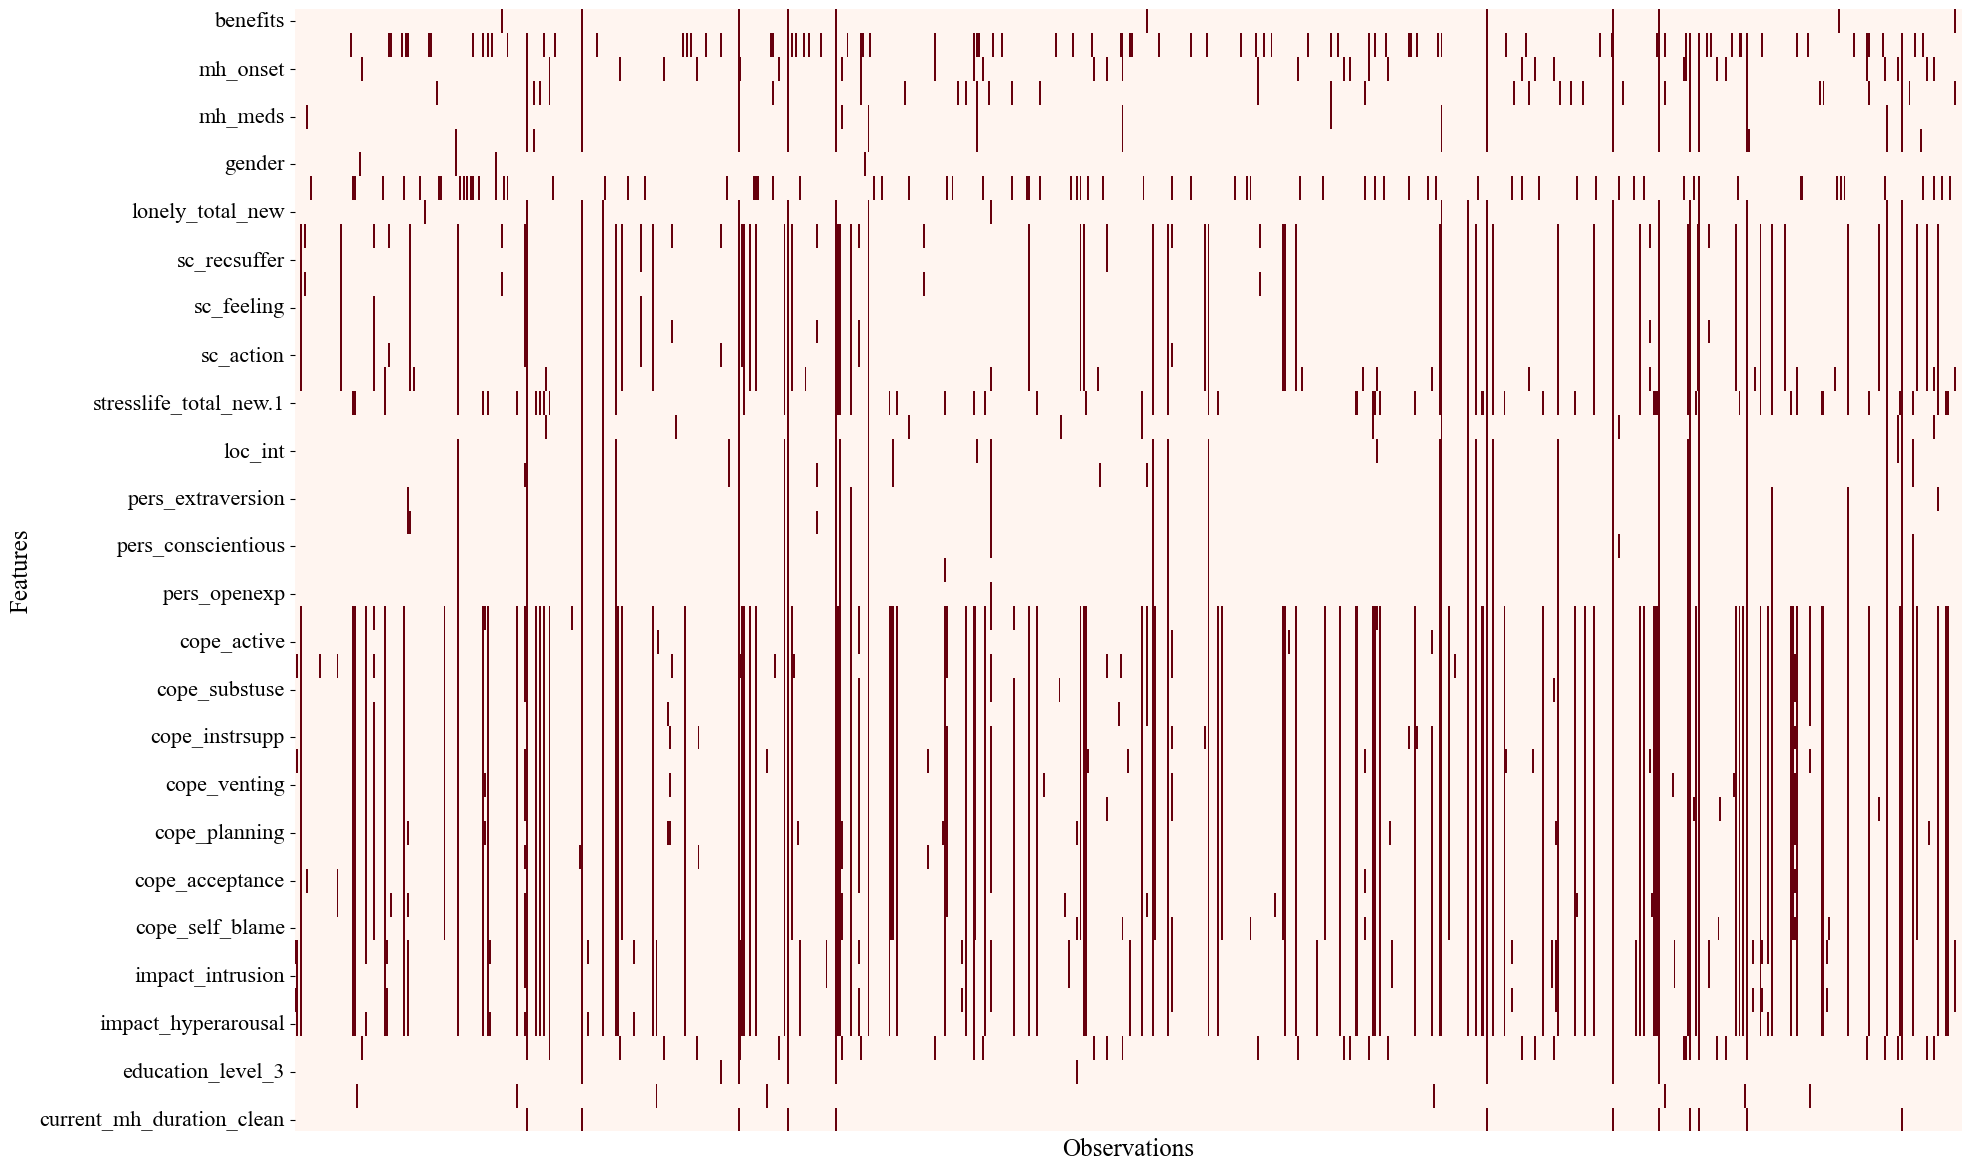

In [207]:
## Heatmap of missing data
cols_with_missing = df_subset_impute.columns[df_subset_impute.isnull().any()]
missing_mask = df_subset_impute[cols_with_missing].isnull()

## Transpose
missing_mask_T = missing_mask.T 

plt.figure(figsize=(20, 12))
sns.heatmap(missing_mask_T, cbar=False, xticklabels=False, cmap="Reds")

plt.ylabel("Features", fontsize=18)
plt.xlabel("Observations", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig("missing_data_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [208]:
## Random Forest Imputation

imputer = IterativeImputer(
    estimator=RandomForestRegressor(),
    max_iter=10,
    random_state=randomstate)

## Fit-transform the data
df_imputed_array = imputer.fit_transform(df_subset_impute)

## Convert back to DataFrame with original column names
df_imputed = pd.DataFrame(df_imputed_array, columns=columns_impute)

print(df_imputed.head())

    age  benefits  previous_mh  mh_onset  mh_other  mh_meds  \
0  49.0       0.0          1.0      31.0       0.0      1.0   
1  33.0       0.0          1.0      23.0       1.0      0.0   
2  70.0       0.0          0.0      67.0       0.0      1.0   
3  29.0       0.0          1.0      25.0       0.0      1.0   
4  58.0       0.0          1.0      28.0       0.0      1.0   

   physical_problems  gender  PHQ9_pre  GAD7_pre  ...  impact_total  \
0                0.0     1.0      18.0      11.0  ...         10.43   
1                0.0     1.0      19.0       8.0  ...         12.91   
2                1.0     1.0       7.0      12.0  ...          6.00   
3                0.0     0.0      13.0      13.0  ...         14.53   
4                1.0     1.0      13.0      12.0  ...         18.00   

   impact_intrusion  impact_avoidance  impact_hyperarousal  mh_onset_cat  \
0              4.00              4.86                 1.00           1.0   
1              4.14              3.95     

In [209]:
categorical_columns = ["benefits", "previous_mh", "mh_meds", "mh_other", "physical_problems", "gender", "employment_status_3", "mh_onset_cat", 
                       "education_level_3", "current_mh_duration_clean", "ethnicity_3", "age_group1", "condition_clean"]  

## Round for categorical variables
for col in categorical_columns:
    df_imputed[col] = df_imputed[col].round().astype(int)

## reset index 
df_imputed.reset_index(drop=True, inplace=True)

In [210]:
## Copy original dataframe
df_full_imputed = df_rr_clean_nooutliers.copy()
df_full_imputed.reset_index(drop=True, inplace=True)
df_full_imputed[columns_impute] = df_imputed

## Replace the imputed columns 
df_full_imputed[columns_impute] = df_imputed

df_full_imputed.to_csv("df_full_imputed_NB_2.csv", index=False)

## Feature selection for ML Models

In [211]:
## Double check for NaNs
features = ["age", "benefits", "previous_mh", "mh_other", "mh_meds", "physical_problems", "gender",	"PHQ9_pre",	"GAD7_pre",
            "WSAS_pre",	"lonely_total_new",	"selfcomp_total", "sc_recsuffer", "sc_universality", "sc_feeling", "sc_tolerance", "sc_action",
            "resilience_total",	"stresslife_total_new.1", "perc_health_total", "loc_int", "loc_ext", "pers_extraversion", "pers_agreeable",
            "pers_conscientious", "pers_emotstab", "pers_openexp", "cope_self_distract", "cope_active", "cope_denial", "cope_substuse",
            "cope_emotsupp", "cope_instrsupp", "cope_behavdisengage", "cope_venting", "cope_posreframe", "cope_planning", "cope_humour", 
            "cope_acceptance", "cope_religion", "cope_self_blame", "impact_total", "impact_intrusion", "impact_avoidance", "impact_hyperarousal",
            "rel_recovery", "mh_onset_cat", "ethnicity_3", "condition_clean", "current_mh_duration_clean", "education_level_3", "employment_status_3"]


df_possible_features = df_full_imputed[features]

df_possible_features.isnull().values.any()

nan_locations = df_possible_features.isnull()

nan_positions = nan_locations.stack()[lambda x: x]
print(nan_positions)


Series([], dtype: bool)


### Correlation

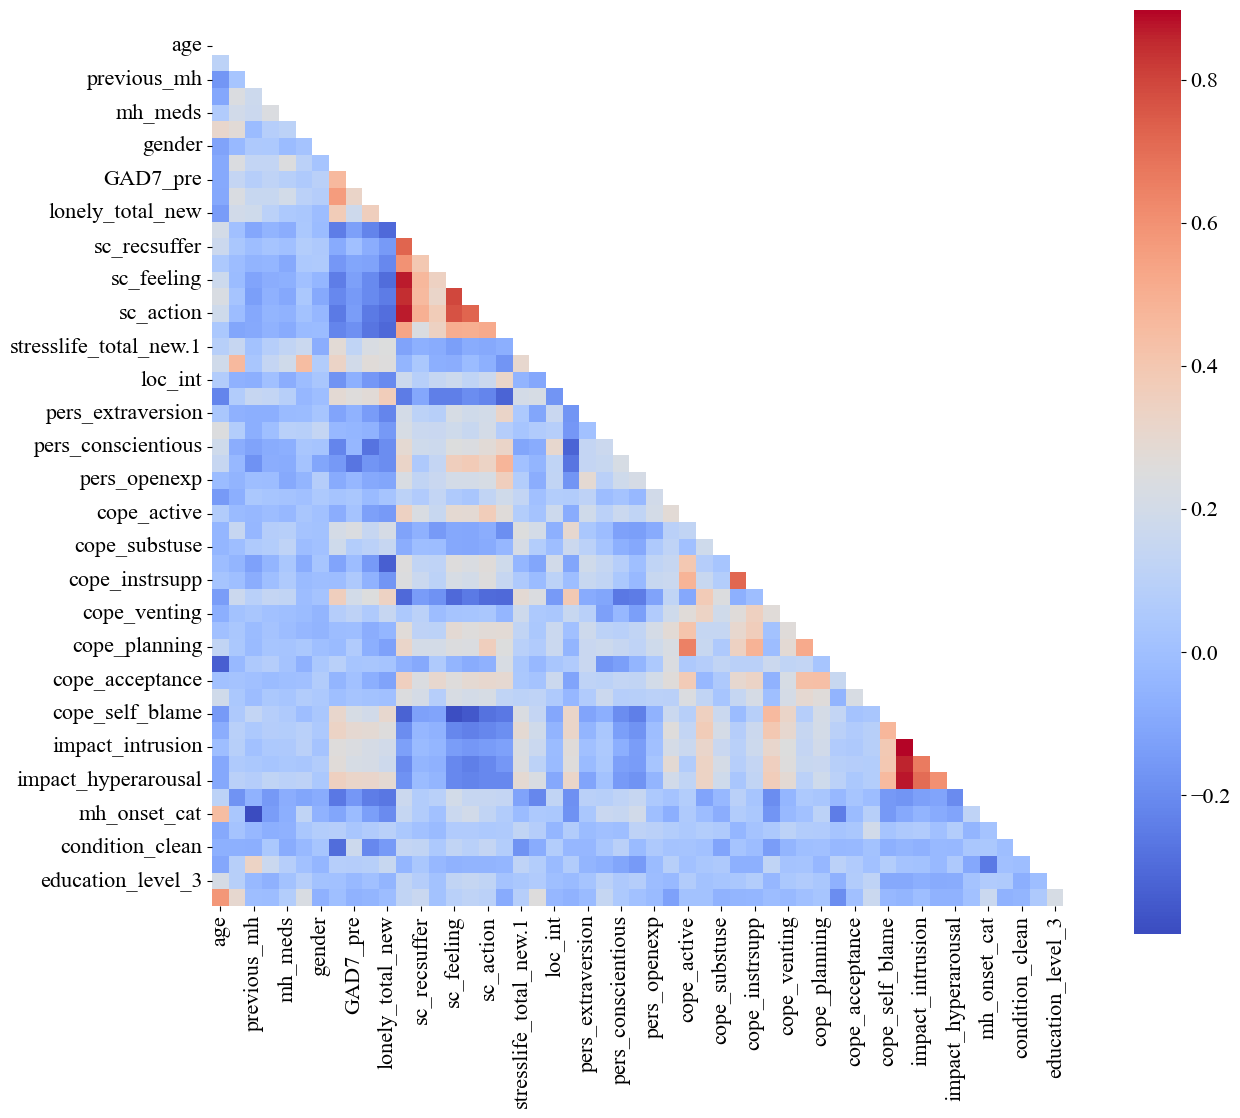

In [212]:
numeric_df = df_possible_features.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

## Only display lower triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", annot=False, square=True)
plt.savefig("feature_corr.png", dpi=300, bbox_inches="tight")

plt.show()

### PCA

In [213]:
## Self compassion subscales
df_possible_features_compassion = df_possible_features[["sc_recsuffer", "sc_universality", "sc_feeling", "sc_tolerance", "sc_action"]]

## Impact subscales
df_possible_features_impact = df_possible_features[["impact_intrusion", "impact_avoidance", "impact_hyperarousal"]]


In [214]:
## Scale features using standard scaler 
scaler_compassion = StandardScaler()
X_scaled_compassion = scaler_compassion.fit_transform(df_possible_features_compassion)

scaler_impact = StandardScaler()
X_scaled_impact = scaler_impact.fit_transform(df_possible_features_impact)

## Apply PCA
pca_compassion = PCA(n_components=1, svd_solver="randomized", random_state=randomstate)
X_pca_compassion = pca_compassion.fit_transform(X_scaled_compassion)

pca_impact = PCA(n_components=1, svd_solver="randomized", random_state=randomstate)
X_pca_impact = pca_impact.fit_transform(X_scaled_impact)

## PCA Component as variable instead 
df_possible_features["self_compassion_pca"] = X_pca_compassion[:, 0]
df_possible_features["impact_pca"] = X_pca_impact[:, 0]



In [215]:
print(df_possible_features["self_compassion_pca"].head(10))
print (pca_compassion.explained_variance_ratio_[0])
print(df_possible_features["impact_pca"].head(10))
print (pca_impact.explained_variance_ratio_[0])


0    2.860311
1    1.561718
2    1.923784
3    0.387200
4    1.906718
5   -1.412967
6   -0.059524
7   -1.883807
8   -1.248097
9    0.359606
Name: self_compassion_pca, dtype: float64
0.6235664568936203
0   -1.429866
1   -0.631870
2   -2.499090
3   -0.079620
4    0.783989
5    1.883902
6    1.324346
7    2.423377
8    0.505535
9   -1.131205
Name: impact_pca, dtype: float64
0.7711712986952561


## Save final clean data frame


In [218]:
df_possible_features.to_csv("df_encoded_models_NB_2.csv", index = False)